# TCC — Mulheres em Liderança na TI

> **Notebook consolidado (v3).**  
> Combina o melhor do original (nomes de colunas RAIS corretos, separador `;`, extensão `.txt`)  
> com as correções do revisado:
> 1. `if __name__ == '__main__'` removido — executa diretamente no Jupyter  
> 2. `fillna('')` antes de `astype(str)` no Parquet — NaN vira `''` e não `'nan'`  
> 3. `df_raca_rais` e `painel_raca_censo` renomeados para evitar colisão de variáveis  
> 4. Totais convertidos para `int` puro antes de serializar para Excel  
> 5. Filtro de TI no Censo vetorizado (sem `apply` linha a linha)  
> 6. Mediana calculada com `np.median` (correto para n par e ímpar)  
> 7. Nome do Excel derivado automaticamente do arquivo RAIS processado  
> 8. `safe_div` definida uma única vez (seção 2.9)  
> 9. Lista de regiões RAIS centralizada em `REGIOES_RAIS`  
> 10. `censo_ies_df` utilizado em join com cursos (categoria administrativa)  
> 11. Gráficos com seaborn/matplotlib estilo aprimorado (do revisado)  


## 0. Imports

In [ ]:
import re
from ftplib import FTP
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import os, glob, subprocess, shutil, tempfile, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq


## 1. Verificação do ambiente (GPU / RAM)

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
    print('Sem GPU conectada')
else:
    print(gpu_info)


Wed Jun 10 12:37:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
try:
    import cupy as cp
    GPU_AVAILABLE = cp.cuda.is_available()
except ImportError:
    GPU_AVAILABLE = False
    cp = np
print('GPU disponível:', GPU_AVAILABLE)


GPU disponível: True


In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print(f'RAM disponível: {ram_gb:.1f} GB')
if ram_gb < 20:
    print('Atenção: runtime sem alta RAM — ajuste CHUNKSIZE se necessário')
else:
    print('Runtime de alta RAM detectado.')


RAM disponível: 54.8 GB
Runtime de alta RAM detectado.


---
## 2. RAIS — Relação Anual de Informações Sociais (2023)

### 2.1 Configuração central

Edite **somente esta célula** para controlar quais arquivos baixar e processar.


In [ ]:
# ============================================================
# CONFIGURAÇÃO CENTRAL — edite aqui
# ============================================================

ANO_RAIS   = 2023
FTP_HOST   = 'ftp.mtps.gov.br'
FTP_DIR    = f'/pdet/microdados/RAIS/{ANO_RAIS}'

# Lista centralizada de regiões a baixar/processar
REGIOES_RAIS = [
    'RAIS_VINC_PUB_SP.7z',
    'RAIS_VINC_PUB_NORTE.7z',
    'RAIS_VINC_PUB_NORDESTE.7z',
    'RAIS_VINC_PUB_SUL.7z',
    'RAIS_VINC_PUB_MG_ES_RJ.7z',
    'RAIS_VINC_PUB_CENTRO_OESTE.7z',
    # 'RAIS_VINC_PUB_NI.7z',  # descomente se quiser incluir registros sem UF
]

ZIP_DIR     = '/content/rais2023_zip'
TXT_DIR     = '/content/rais2023_txt'
PARQUET_DIR = '/content/rais2023_parquet'
OUTPUT_DIR  = '/content/outputs'

FILTRAR_ATIVO = False
CHUNKSIZE     = 500_000

for d in [ZIP_DIR, TXT_DIR, PARQUET_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print('Configuração carregada.')
print(f'Regiões a baixar: {len(REGIOES_RAIS)}')


Configuração carregada.
Regiões a baixar: 6


### 2.2 Listar arquivos disponíveis no FTP

In [ ]:
try:
    with FTP(FTP_HOST, timeout=30) as ftp:
        ftp.encoding = 'latin-1'
        ftp.login()
        ftp.cwd(FTP_DIR)
        ftp_files = []
        ftp.retrlines('NLST', ftp_files.append)
    print(f'Arquivos em {FTP_HOST}{FTP_DIR} ({len(ftp_files)} itens):')
    for f in ftp_files:
        print(' -', f)
except Exception as e:
    print('[AVISO] Não foi possível listar o FTP:', e)


Arquivos em ftp.mtps.gov.br/pdet/microdados/RAIS/2023 (10 itens):
 - Comunicado - Microdados RAIS 2024  Ministério do Trabalho e Emprego.htm
 - Legado
 - RAIS_ESTAB_PUB.7z
 - RAIS_VINC_PUB_CENTRO_OESTE.7z
 - RAIS_VINC_PUB_MG_ES_RJ.7z
 - RAIS_VINC_PUB_NI.7z
 - RAIS_VINC_PUB_NORDESTE.7z
 - RAIS_VINC_PUB_NORTE.7z
 - RAIS_VINC_PUB_SP.7z
 - RAIS_VINC_PUB_SUL.7z


### 2.3 Download dos arquivos .7z

In [ ]:
def _has_cmd(cmd):
    return shutil.which(cmd) is not None

def _ensure_7z():
    if not _has_cmd('7z'):
        print('[INFO] Instalando p7zip-full...')
        subprocess.run(['apt-get', 'update', '-y'], check=True)
        subprocess.run(['apt-get', 'install', '-y', 'p7zip-full'], check=True)

def _ensure_aria2():
    if not _has_cmd('aria2c'):
        print('[INFO] Instalando aria2...')
        subprocess.run(['apt-get', 'update', '-y'], check=True)
        subprocess.run(['apt-get', 'install', '-y', 'aria2'], check=True)


def download_rais(
    regioes, zip_dir,
    ftp_host=None, ftp_dir=None,
    prefer_aria2=True, aria2_conns=8, aria2_parallel=4, stall_timeout=180,
):
    ftp_host = ftp_host or FTP_HOST
    ftp_dir  = ftp_dir  or FTP_DIR
    base_url = f'ftp://{ftp_host}{ftp_dir}'
    urls = [f'{base_url}/{r}' for r in regioes]

    def _wget(urls_list):
        for url in urls_list:
            dest = os.path.join(zip_dir, os.path.basename(url))
            print(f'[wget] {url}')
            subprocess.run(
                ['wget', '-c', '--tries=15', '--timeout=60', '--no-verbose', '-O', dest, url],
                check=True,
            )

    def _aria2(urls_list):
        _ensure_aria2()
        with tempfile.NamedTemporaryFile('w', delete=False, suffix='.txt') as f:
            for u in urls_list:
                f.write(u + '\n')
            list_path = f.name
        log_path = os.path.join(zip_dir, 'aria2.log')
        cmd = [
            'aria2c', '-i', list_path, '-d', zip_dir,
            '-x', str(aria2_conns), '-s', str(aria2_conns),
            '-j', str(aria2_parallel), '-c',
            '--ftp-pasv=true', '--file-allocation=none',
            '--auto-file-renaming=false', '--console-log-level=warn',
            '--log', log_path, '--log-level=notice',
        ]
        proc = subprocess.Popen(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        last_sizes, last_change = {}, time.time()
        try:
            while proc.poll() is None:
                progressed = False
                for u in urls_list:
                    dest = os.path.join(zip_dir, os.path.basename(u))
                    try:
                        sz = os.path.getsize(dest)
                    except FileNotFoundError:
                        sz = 0
                    if last_sizes.get(dest) != sz:
                        last_sizes[dest] = sz
                        progressed = True
                if progressed:
                    last_change = time.time()
                elif time.time() - last_change > stall_timeout:
                    proc.terminate()
                    time.sleep(2)
                    if proc.poll() is None:
                        proc.kill()
                    raise TimeoutError('aria2c estagnou.')
                time.sleep(3)
        finally:
            if os.path.exists(list_path):
                os.unlink(list_path)
        if proc.returncode != 0:
            raise RuntimeError(f'aria2c falhou — veja {log_path}')

    try:
        if prefer_aria2:
            _aria2(urls)
        else:
            _wget(urls)
    except Exception as e:
        print(f'[AVISO] aria2c falhou ({e}), tentando wget...')
        _wget(urls)
    print(f'\n✅ Download concluído: {len(regioes)} arquivo(s).')


download_rais(REGIOES_RAIS, ZIP_DIR)


[INFO] Instalando aria2...

✅ Download concluído: 6 arquivo(s).


### 2.4 Extrair .7z → .txt

In [ ]:
def extract_all_7z(zip_dir, txt_dir):
    _ensure_7z()
    os.makedirs(txt_dir, exist_ok=True)
    archives = sorted(glob.glob(os.path.join(zip_dir, '*.7z')))
    if not archives:
        print(f'[AVISO] Nenhum .7z encontrado em {zip_dir}')
        return []
    print(f'[INFO] {len(archives)} arquivo(s) para extrair.')
    for path in archives:
        nome = os.path.basename(path)
        print(f'  Extraindo {nome}...')
        res = subprocess.run(
            ['7z', 'x', '-y', path, f'-o{txt_dir}'],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        status = '[OK]' if res.returncode == 0 else '[ERRO]'
        print(f'  {status} {nome}')

    # CORREÇÃO: recursive=True para encontrar TXTs dentro de subpastas
    txts = sorted(glob.glob(f'{txt_dir}/**/*.txt', recursive=True))
    print(f'\n✅ {len(txts)} arquivo(s) .txt extraidos.')
    return txts


txts = extract_all_7z(ZIP_DIR, TXT_DIR)

# TXT_FILES definido aqui, após extração, com recursive=True
# CORREÇÃO: extensão real é .COMT, não .txt
TXT_FILES = sorted(glob.glob(f'{TXT_DIR}/*.COMT'))

print(f'\nArquivos prontos para processar ({len(TXT_FILES)}):')
for f in TXT_FILES:
    print(' -', os.path.basename(f))

[INFO] 6 arquivo(s) para extrair.
  Extraindo RAIS_VINC_PUB_CENTRO_OESTE.7z...
  [OK] RAIS_VINC_PUB_CENTRO_OESTE.7z
  Extraindo RAIS_VINC_PUB_MG_ES_RJ.7z...
  [OK] RAIS_VINC_PUB_MG_ES_RJ.7z
  Extraindo RAIS_VINC_PUB_NORDESTE.7z...
  [OK] RAIS_VINC_PUB_NORDESTE.7z
  Extraindo RAIS_VINC_PUB_NORTE.7z...
  [OK] RAIS_VINC_PUB_NORTE.7z
  Extraindo RAIS_VINC_PUB_SP.7z...
  [OK] RAIS_VINC_PUB_SP.7z
  Extraindo RAIS_VINC_PUB_SUL.7z...
  [OK] RAIS_VINC_PUB_SUL.7z

✅ 0 arquivo(s) .txt extraidos.

Arquivos prontos para processar (6):
 - RAIS_VINC_PUB_CENTRO_OESTE.COMT
 - RAIS_VINC_PUB_MG_ES_RJ.COMT
 - RAIS_VINC_PUB_NORDESTE.COMT
 - RAIS_VINC_PUB_NORTE.COMT
 - RAIS_VINC_PUB_SP.COMT
 - RAIS_VINC_PUB_SUL.COMT


### 2.5 Inspeção rápida do primeiro arquivo

In [ ]:
# Lê as primeiras 5 linhas para confirmar separador e colunas
sample = pd.read_csv(TXT_FILES[0], sep=',', encoding='latin1', nrows=5, low_memory=False)
print('Colunas:', sample.columns.tolist())
display(sample)


Colunas: ['Bairros SP - Código', 'Bairros Fortaleza - Código', 'Bairros RJ - Código', 'Causa Afastamento 1 - Código', 'Causa Afastamento 2 - Código', 'Causa Afastamento 3 - Código', 'Motivo Desligamento - Código', 'CBO 2002 Ocupação - Código', 'CNAE 2.0 Classe - Código', 'CNAE 95 Classe - Código', 'Distritos SP - Código', 'Ind Vínculo Ativo 31/12 - Código', 'Faixa Etária - Código', 'Faixa Rem Média (SM) - Código', 'Faixa Hora Contrat - Código', 'Faixa Rem Dez (SM) - Código', 'Faixa Tempo Emprego - Código', 'Escolaridade Após 2005 - Código', 'Qtd Hora Contr', 'Idade', 'Ind CEI Vinculado - Código', 'Ind Estabelecimento Participante SIMPLES - Código', 'Mês Admissão - Código', 'Mês Desligamento - Código', 'Município Trab - Código', 'Município - Código', 'Nacionalidade - Código', 'Natureza Jurídica - Código', 'Ind Portador Defic - Código', 'Qtd Dias Afastamento', 'Raça Cor - Código', 'Região Adm DF - Código', 'Vl Rem Dezembro Nom', 'Vl Rem Dezembro (SM)', 'Vl Rem Média Nom', 'Vl Rem Média (

,Bairros SP - Código,Bairros Fortaleza - Código,Bairros RJ - Código,Causa Afastamento 1 - Código,Causa Afastamento 2 - Código,Causa Afastamento 3 - Código,Motivo Desligamento - Código,CBO 2002 Ocupação - Código,CNAE 2.0 Classe - Código,CNAE 95 Classe - Código,...,Vl Rem Julho SC,Vl Rem Agosto SC,Vl Rem Setembro SC,Vl Rem Outubro SC,Vl Rem Novembro SC,Ano Chegada Brasil,Ind Trabalho Intermitente - Código,Ind Trabalho Parcial - Código,Ind Vínculo Abandonado - Código,Categoria Trabalhador - Código
0,999997,999997,999997,999,999,999,21,763105,13511,17418,...,0.00,0.00,0.00,0.00,0.00,1198,0,0,0,101
1,999997,999997,999997,999,999,999,12,763010,14126,18120,...,1552.55,771.28,0.00,0.00,0.00,1198,0,0,0,101
2,999997,999997,999997,999,999,999,0,521110,18130,22225,...,0.00,0.00,0.00,0.00,0.00,1198,0,0,0,101
3,999997,999997,999997,40,999,999,0,848505,10121,15121,...,2489.33,1929.78,1949.88,1929.34,2133.42,1198,0,0,0,101
4,999997,999997,999997,999,999,999,0,784205,10121,15121,...,1445.17,1570.05,1539.50,1618.11,1615.17,1198,0,0,0,101


### 2.6 Conversão TXT → Parquet (streaming)

> Execute **uma única vez**. Arquivos ~60–70% menores, leitura muito mais rápida depois.


In [ ]:
def convert_txt_to_parquet(
    txt_path, output_dir,
    sep=';', encoding='latin1', chunksize=500_000, on_bad_lines='skip',
):
    """Converte um TXT para Parquet em streaming (todos os campos como string).
    fillna('') antes de astype(str) — NaN vira '' e não 'nan'.
    """
    os.makedirs(output_dir, exist_ok=True)
    stem = Path(txt_path).stem
    out_path = os.path.join(output_dir, f'{stem}.parquet')
    print(f'Convertendo: {stem}.txt -> {stem}.parquet')
    reader = pd.read_csv(
        txt_path, sep=sep, encoding=encoding,
        low_memory=False, chunksize=chunksize, on_bad_lines=on_bad_lines,
    )
    writer = schema = None
    total = 0
    for i, chunk in enumerate(reader, 1):
        for c in chunk.columns:
            chunk[c] = chunk[c].fillna('').astype(str)   # ← NaN → '' (não 'nan')
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        if writer is None:
            schema = pa.schema([pa.field(n, pa.string()) for n in table.schema.names])
            table = table.cast(schema)
            writer = pq.ParquetWriter(out_path, schema, compression='snappy')
        else:
            if table.schema != schema:
                cols = [
                    table.column(n) if n in table.schema.names
                    else pa.array([''] * len(table), type=pa.string())
                    for n in schema.names
                ]
                table = pa.Table.from_arrays(cols, schema=schema)
                if table.schema != schema:
                    table = table.cast(schema)
        writer.write_table(table)
        total += len(chunk)
        print(f'  chunk {i}: {len(chunk):,} linhas')
    if writer:
        writer.close()
        print(f'Salvo: {out_path} ({total:,} linhas)')
    else:
        print('Nenhum dado lido.')
    return out_path


def batch_convert(input_dir, output_dir, pattern='*.txt', **kw):
    files = sorted(glob.glob(os.path.join(input_dir, pattern)))
    print(f'{len(files)} arquivo(s) encontrados para conversão.')
    for f in files:
        convert_txt_to_parquet(f, output_dir, **kw)


# Executa diretamente no notebook (sem if __name__ == '__main__')
batch_convert(TXT_DIR, PARQUET_DIR, sep=',', encoding='latin1',
              chunksize=CHUNKSIZE, on_bad_lines='skip',
              pattern='*.COMT')

print('\nConversão concluída.')

6 arquivo(s) encontrados para conversão.
Convertendo: RAIS_VINC_PUB_CENTRO_OESTE.txt -> RAIS_VINC_PUB_CENTRO_OESTE.parquet
  chunk 1: 500,000 linhas
  chunk 2: 500,000 linhas
  chunk 3: 500,000 linhas
  chunk 4: 500,000 linhas
  chunk 5: 500,000 linhas
  chunk 6: 500,000 linhas
  chunk 7: 500,000 linhas
  chunk 8: 500,000 linhas
  chunk 9: 500,000 linhas
  chunk 10: 500,000 linhas
  chunk 11: 500,000 linhas
  chunk 12: 500,000 linhas
  chunk 13: 500,000 linhas
  chunk 14: 500,000 linhas
  chunk 15: 500,000 linhas
  chunk 16: 500,000 linhas
  chunk 17: 247,439 linhas
Salvo: /content/rais2023_parquet/RAIS_VINC_PUB_CENTRO_OESTE.parquet (8,247,439 linhas)
Convertendo: RAIS_VINC_PUB_MG_ES_RJ.txt -> RAIS_VINC_PUB_MG_ES_RJ.parquet
  chunk 1: 500,000 linhas
  chunk 2: 500,000 linhas
  chunk 3: 500,000 linhas
  chunk 4: 500,000 linhas
  chunk 5: 500,000 linhas
  chunk 6: 500,000 linhas
  chunk 7: 500,000 linhas
  chunk 8: 500,000 linhas
  chunk 9: 500,000 linhas
  chunk 10: 500,000 linhas
  chu

### 2.7 Parâmetros e dicionários da análise RAIS

In [ ]:
# ===================== NOMES DAS COLUNAS (RAIS 2023 - separador ;) =====================
# Estes são os nomes reais dos cabeçalhos nos arquivos RAIS .txt
CNAE_COL    = "CNAE 2.0 Subclasse - Codigo"
SEXO_COL    = "Sexo - Código"
RACA_COL    = "Raça Cor - Código"
CBO_COL     = "CBO 2002 Ocupação - Código"
IDADE_COL   = "Idade"
ESCOLAR_COL = "Escolaridade Após 2005 - Código"
ATIVO_COL   = "Ind Vínculo Ativo 31/12 - Código"

USECOLS = (
    [CNAE_COL, SEXO_COL, RACA_COL, CBO_COL, IDADE_COL, ESCOLAR_COL]
    + ([ATIVO_COL] if FILTRAR_ATIVO else [])
)

DTYPE = {
    CBO_COL:     'object',
    SEXO_COL:    'object',
    RACA_COL:    'object',
    IDADE_COL:   'object',
    ESCOLAR_COL: 'object',
}
if FILTRAR_ATIVO:
    DTYPE[ATIVO_COL] = 'object'

# ===================== MAPAS OFICIAIS =====================
MAP_RACA_OFICIAL = {1:"Indígena", 2:"Branca", 4:"Preta", 6:"Amarela", 8:"Parda", 9:"Não informado"}
MAP_ESCOLAR = {
    1:"Analfabeto", 2:"Até 5º ano EF incompleto", 3:"5º ano EF completo",
    4:"6º-9º EF incompleto", 5:"Ensino Fundamental completo",
    6:"Ensino Médio incompleto", 7:"Ensino Médio completo",
    8:"Educação Superior incompleta", 9:"Educação Superior completa",
    10:"Mestrado completo", 11:"Doutorado completo",
}

def map_raca_fn(s):
    return pd.to_numeric(s, errors="coerce").astype("Int16").map(MAP_RACA_OFICIAL).fillna("Não informado")

def map_escolar_fn(s):
    return pd.to_numeric(s, errors="coerce").astype("Int16").map(MAP_ESCOLAR).fillna("Não informado")

# ===================== DICIONÁRIO CBO (TI) =====================
cbo_nome = {
    "203105": "Pesquisador em ciências da computação e informática",
    "212205": "Engenheiro de aplicativos em computação",
    "212210": "Engenheiro de equipamentos em computação",
    "212215": "Engenheiro de sistemas operacionais em computação",
    "212405": "Analista de desenvolvimento de sistemas",
    "212410": "Analista de redes e de comunicação de dados",
    "212415": "Analista de sistemas de automação",
    "212420": "Analista de suporte computacional",
    "212425": "Arquiteto de soluções de tecnologia da informação",
    "212430": "Analista de testes de tecnologia da informação",
    "234120": "Professor de computação (ensino superior)",
    "313220": "Técnico em manutenção de equipamentos de informática",
    "317105": "Desenvolvedor web (técnico)",
    "317110": "Desenvolvedor de sistemas de TI (técnico)",
    "317115": "Prog. de máquinas-ferramenta c/ comando numérico",
    "317120": "Desenvolvedor de multimídia",
    "317205": "Operador de sistemas computacionais em rede",
    "317210": "Técnico de suporte ao usuário de TI",
    "372205": "Operador de rede de teleprocessamento",
    # Liderança / gestão
    "123605": "Diretor de TI",
    "142505": "Gerente de infraestrutura de TI",
    "142510": "Gerente de desenvolvimento de sistemas",
    "142515": "Gerente de operação de TI",
    "142520": "Gerente de projetos de TI",
    "142525": "Gerente de segurança da informação",
    "142530": "Gerente de suporte técnico de TI",
    "142535": "Tecnólogo em gestão de TI",
    "212305": "Administrador de banco de dados",
    "212310": "Administrador de redes",
    "212315": "Administrador de sistemas operacionais",
    "212320": "Administrador em segurança da informação",
}
CBO_TI_SET    = set(cbo_nome.keys())
CBO_LIDER_SET = {
    "123605","142505","142510","142515","142520",
    "142525","142530","142535","212305","212310","212315","212320",
}

def cnae_is_ti(s):
    return s.astype(str).str.strip().str.replace(r'[.\-\s"]', '', regex=True).str.startswith(('62','63'))


### 2.8 Processamento em chunks (todas as regiões)

In [ ]:
# ===================== ACUMULADORES — sempre zerados ao rodar a célula =====================
tot_mulheres_ti  = tot_homens_ti  = 0
tot_mulheres_lid = tot_homens_lid = 0
raca_counts         = Counter(); raca_lid_counts     = Counter()
escolar_counts      = Counter(); escolar_lid_counts  = Counter()
cargo_counts        = Counter()
idade_freq          = defaultdict(int)
idade_lid_freq      = defaultdict(int)
cbo_pre_filtro      = Counter()
cbo_removidos       = Counter()
total_cnae_ti       = 0

assert TXT_FILES, (
    f'Nenhum TXT encontrado em {TXT_DIR}. '
    'Rode a extração 7z antes de continuar.'
)

for txt_path in TXT_FILES:
    regiao = os.path.basename(txt_path).replace('RAIS_VINC_PUB_', '').replace('.COMT', '')
    print(f'\n>>> Processando: {regiao}...')

    antes_mulheres = tot_mulheres_ti
    antes_homens   = tot_homens_ti

    reader = pd.read_csv(
        txt_path, sep=',', encoding='latin1',
        usecols=USECOLS, dtype=DTYPE,
        low_memory=False, on_bad_lines='skip',
        chunksize=CHUNKSIZE,
    )

    for chunk in reader:
        if FILTRAR_ATIVO:
            chunk = chunk.loc[chunk[ATIVO_COL].eq(1)]

        mask_ti = cnae_is_ti(chunk[CNAE_COL])
        if not mask_ti.any():
            continue
        ti = chunk.loc[mask_ti].copy()

        ti[SEXO_COL]    = pd.to_numeric(ti[SEXO_COL],    errors='coerce').astype('Int8')
        ti[RACA_COL]    = pd.to_numeric(ti[RACA_COL],    errors='coerce').astype('Int16')
        ti[IDADE_COL]   = pd.to_numeric(ti[IDADE_COL],   errors='coerce').astype('Int16')
        ti[ESCOLAR_COL] = pd.to_numeric(ti[ESCOLAR_COL], errors='coerce').astype('Int16')

        ti['CBO_norm'] = ti[CBO_COL].astype(str).str.replace(r'[.\-\s]', '', regex=True)
        total_cnae_ti += len(ti)
        cbo_pre_filtro.update(ti['CBO_norm'].tolist())

        mask_cbo = ti['CBO_norm'].isin(CBO_TI_SET)
        cbo_removidos.update(ti.loc[~mask_cbo, 'CBO_norm'].tolist())
        ti = ti.loc[mask_cbo].copy()
        if ti.empty:
            continue

        mulheres = ti.loc[ti[SEXO_COL].eq(2)]
        homens   = ti.loc[ti[SEXO_COL].eq(1)]
        tot_mulheres_ti += len(mulheres)
        tot_homens_ti   += len(homens)

        m_lid = mulheres.loc[mulheres['CBO_norm'].isin(CBO_LIDER_SET)]
        h_lid = homens.loc[homens['CBO_norm'].isin(CBO_LIDER_SET)]
        tot_mulheres_lid += len(m_lid)
        tot_homens_lid   += len(h_lid)

        cargo_counts.update(mulheres['CBO_norm'].tolist())
        raca_counts.update(map_raca_fn(mulheres[RACA_COL]).value_counts().to_dict())
        raca_lid_counts.update(map_raca_fn(m_lid[RACA_COL]).value_counts().to_dict())
        escolar_counts.update(map_escolar_fn(mulheres[ESCOLAR_COL]).value_counts().to_dict())
        escolar_lid_counts.update(map_escolar_fn(m_lid[ESCOLAR_COL]).value_counts().to_dict())

        for serie, freq in [(mulheres[IDADE_COL], idade_freq),
                            (m_lid[IDADE_COL],    idade_lid_freq)]:
            idades = pd.to_numeric(serie, errors='coerce').dropna().astype(int)
            for k, v in idades.value_counts().items():
                freq[int(k)] += int(v)

    print(f'    Mulheres TI: {tot_mulheres_ti - antes_mulheres:,}  |  Homens TI: {tot_homens_ti - antes_homens:,}')

print(f'\n=== BRASIL COMPLETO ===')
print(f'  CNAE 62/63 (antes CBO): {total_cnae_ti:,}')
print(f'  Mulheres TI (pós CBO):  {tot_mulheres_ti:,}')
print(f'  Homens TI (pós CBO):    {tot_homens_ti:,}')

if cbo_removidos:
    top_rem = pd.DataFrame(cbo_removidos.most_common(10), columns=['CBO removido', 'Qtd'])
    print('\nTop 10 CBOs removidos (não TI):')
    print(top_rem.to_string(index=False))


>>> Processando: CENTRO_OESTE...
    Mulheres TI: 8,510  |  Homens TI: 31,919

>>> Processando: MG_ES_RJ...
    Mulheres TI: 18,111  |  Homens TI: 65,722

>>> Processando: NORDESTE...
    Mulheres TI: 7,740  |  Homens TI: 28,325

>>> Processando: NORTE...
    Mulheres TI: 818  |  Homens TI: 3,960

>>> Processando: SP...
    Mulheres TI: 48,213  |  Homens TI: 173,214

>>> Processando: SUL...
    Mulheres TI: 24,219  |  Homens TI: 82,512

=== BRASIL COMPLETO ===
  CNAE 62/63 (antes CBO): 1,066,136
  Mulheres TI (pós CBO):  107,611
  Homens TI (pós CBO):    385,652

Top 10 CBOs removidos (não TI):
CBO removido   Qtd
      411010 64896
      411005 44267
      142330 29823
      514320 18345
      252105 16842
      354125 13601
      142335 13499
      354120 11542
      252405 11306
      410105 10211


### 2.9 Cálculo dos indicadores

In [ ]:
# safe_div definida uma única vez — usada em RAIS e Censo
def safe_div(a, b):
    return np.where(b > 0, a / b, np.nan)


def build_age_df(freq_all, freq_lid, total):
    bins   = [0, 24, 29, 34, 39, 44, 49, 200]
    labels = ['<=24','25-29','30-34','35-39','40-44','45-49','50+']
    if not freq_all:
        return pd.DataFrame(columns=['Faixa','Qtd','Líderes','% Mulheres TI','% Mulheres Líderes'])
    df = pd.Series(freq_all).rename_axis('Idade').reset_index(name='Qtd')
    df['Faixa'] = pd.cut(df['Idade'], bins=bins, labels=labels, include_lowest=True)
    df = df.groupby('Faixa', observed=False)['Qtd'].sum().reindex(labels, fill_value=0).reset_index()
    if freq_lid:
        dl = pd.Series(freq_lid).rename_axis('Idade').reset_index(name='Qtd')
        dl['Faixa'] = pd.cut(dl['Idade'], bins=bins, labels=labels, include_lowest=True)
        dl = dl.groupby('Faixa', observed=False)['Qtd'].sum()
        df['Líderes'] = df['Faixa'].map(dl).fillna(0).astype(int)
    else:
        df['Líderes'] = 0
    df['% Mulheres TI']      = (100 * safe_div(df['Qtd'], total)).round(2)
    df['% Mulheres Líderes'] = (100 * safe_div(df['Líderes'], df['Qtd'])).round(2)
    return df


assert tot_mulheres_ti > 0 or tot_homens_ti > 0, 'Nenhum dado após filtros.'

# Garantir int puro para serialização Excel
total_ti  = int(tot_mulheres_ti + tot_homens_ti)
total_lid = int(tot_mulheres_lid + tot_homens_lid)
tot_mulheres_ti  = int(tot_mulheres_ti)
tot_homens_ti    = int(tot_homens_ti)
tot_mulheres_lid = int(tot_mulheres_lid)
tot_homens_lid   = int(tot_homens_lid)

summary_genero = pd.DataFrame({
    'Gênero':                         ['Mulheres', 'Homens'],
    'Total em TI':                    [tot_mulheres_ti, tot_homens_ti],
    '% no Setor TI':                  [round(100*tot_mulheres_ti/total_ti, 2),
                                       round(100*tot_homens_ti/total_ti, 2)],
    'Total Líderes TI':               [tot_mulheres_lid, tot_homens_lid],
    'Taxa liderança no gênero (%)':   [round(float(100*safe_div(tot_mulheres_lid, tot_mulheres_ti)), 2),
                                       round(float(100*safe_div(tot_homens_lid,   tot_homens_ti)),   2)],
    'Participação entre líderes (%)': [round(float(100*safe_div(tot_mulheres_lid, total_lid)), 2),
                                       round(float(100*safe_div(tot_homens_lid,   total_lid)), 2)],
})

# df_raca_rais — prefixo _rais para não colidir com variáveis do Censo
df_raca_rais = pd.DataFrame(
    sorted(raca_counts.items(), key=lambda x: -x[1]), columns=['Raça', 'Qtd']
)
if not df_raca_rais.empty:
    df_raca_rais['Líderes']            = df_raca_rais['Raça'].map(raca_lid_counts).fillna(0).astype(int)
    df_raca_rais['% Mulheres TI']      = (100 * df_raca_rais['Qtd'] / tot_mulheres_ti).round(2)
    df_raca_rais['% Mulheres Líderes'] = (100 * safe_div(df_raca_rais['Líderes'], df_raca_rais['Qtd'])).round(2)

df_escolar_rais = pd.DataFrame(
    sorted(escolar_counts.items(), key=lambda x: -x[1]), columns=['Escolaridade', 'Qtd']
)
if not df_escolar_rais.empty:
    df_escolar_rais['Líderes']            = df_escolar_rais['Escolaridade'].map(escolar_lid_counts).fillna(0).astype(int)
    df_escolar_rais['% Mulheres TI']      = (100 * df_escolar_rais['Qtd'] / tot_mulheres_ti).round(2)
    df_escolar_rais['% Mulheres Líderes'] = (100 * safe_div(df_escolar_rais['Líderes'], df_escolar_rais['Qtd'])).round(2)

df_idade_rais = build_age_df(idade_freq, idade_lid_freq, tot_mulheres_ti)

# Mediana com np.median — correto para n par e ímpar
if idade_freq:
    idades_exp    = np.repeat(list(idade_freq.keys()), list(idade_freq.values()))
    idade_media   = round(float(np.mean(idades_exp)), 2)
    idade_mediana = float(np.median(idades_exp))
else:
    idade_media = idade_mediana = np.nan

top_cargos_rais = pd.DataFrame(cargo_counts.most_common(20), columns=['CBO', 'Qtd'])
top_cargos_rais['Cargo'] = top_cargos_rais['CBO'].map(cbo_nome)
top_cargos_rais['% entre mulheres TI'] = (100 * top_cargos_rais['Qtd'] / tot_mulheres_ti).round(2)
top_cargos_rais = top_cargos_rais[['Cargo', 'Qtd', '% entre mulheres TI']]

# === Prints ===
print('=== VISÃO GERAL DE GÊNERO ===')
print(summary_genero.to_string(index=False))
if not df_raca_rais.empty:
    print('\n=== RAÇA (MULHERES TI) ===')
    print(df_raca_rais.to_string(index=False))
if not df_escolar_rais.empty:
    print('\n=== ESCOLARIDADE (MULHERES TI) ===')
    print(df_escolar_rais.to_string(index=False))
if not df_idade_rais.empty:
    print('\n=== FAIXA ETÁRIA (MULHERES TI) ===')
    print(df_idade_rais.to_string(index=False))
print(f'\nIdade média: {idade_media}  |  Mediana: {idade_mediana}')


=== VISÃO GERAL DE GÊNERO ===
  Gênero  Total em TI  % no Setor TI  Total Líderes TI  Taxa liderança no gênero (%)  Participação entre líderes (%)
Mulheres       107611          21.82             14478                         13.45                           23.81
  Homens       385652          78.18             46340                         12.02                           76.19

=== RAÇA (MULHERES TI) ===
         Raça   Qtd  Líderes  % Mulheres TI  % Mulheres Líderes
       Branca 66022    10002          61.35               15.15
        Parda 25983     2763          24.15               10.63
Não informado  7169      717           6.66               10.00
        Preta  5987      609           5.56               10.17
      Amarela  2224      353           2.07               15.87
     Indígena   226       34           0.21               15.04

=== ESCOLARIDADE (MULHERES TI) ===
                Escolaridade   Qtd  Líderes  % Mulheres TI  % Mulheres Líderes
  Educação Superior completa

### 2.10 Gráficos RAIS

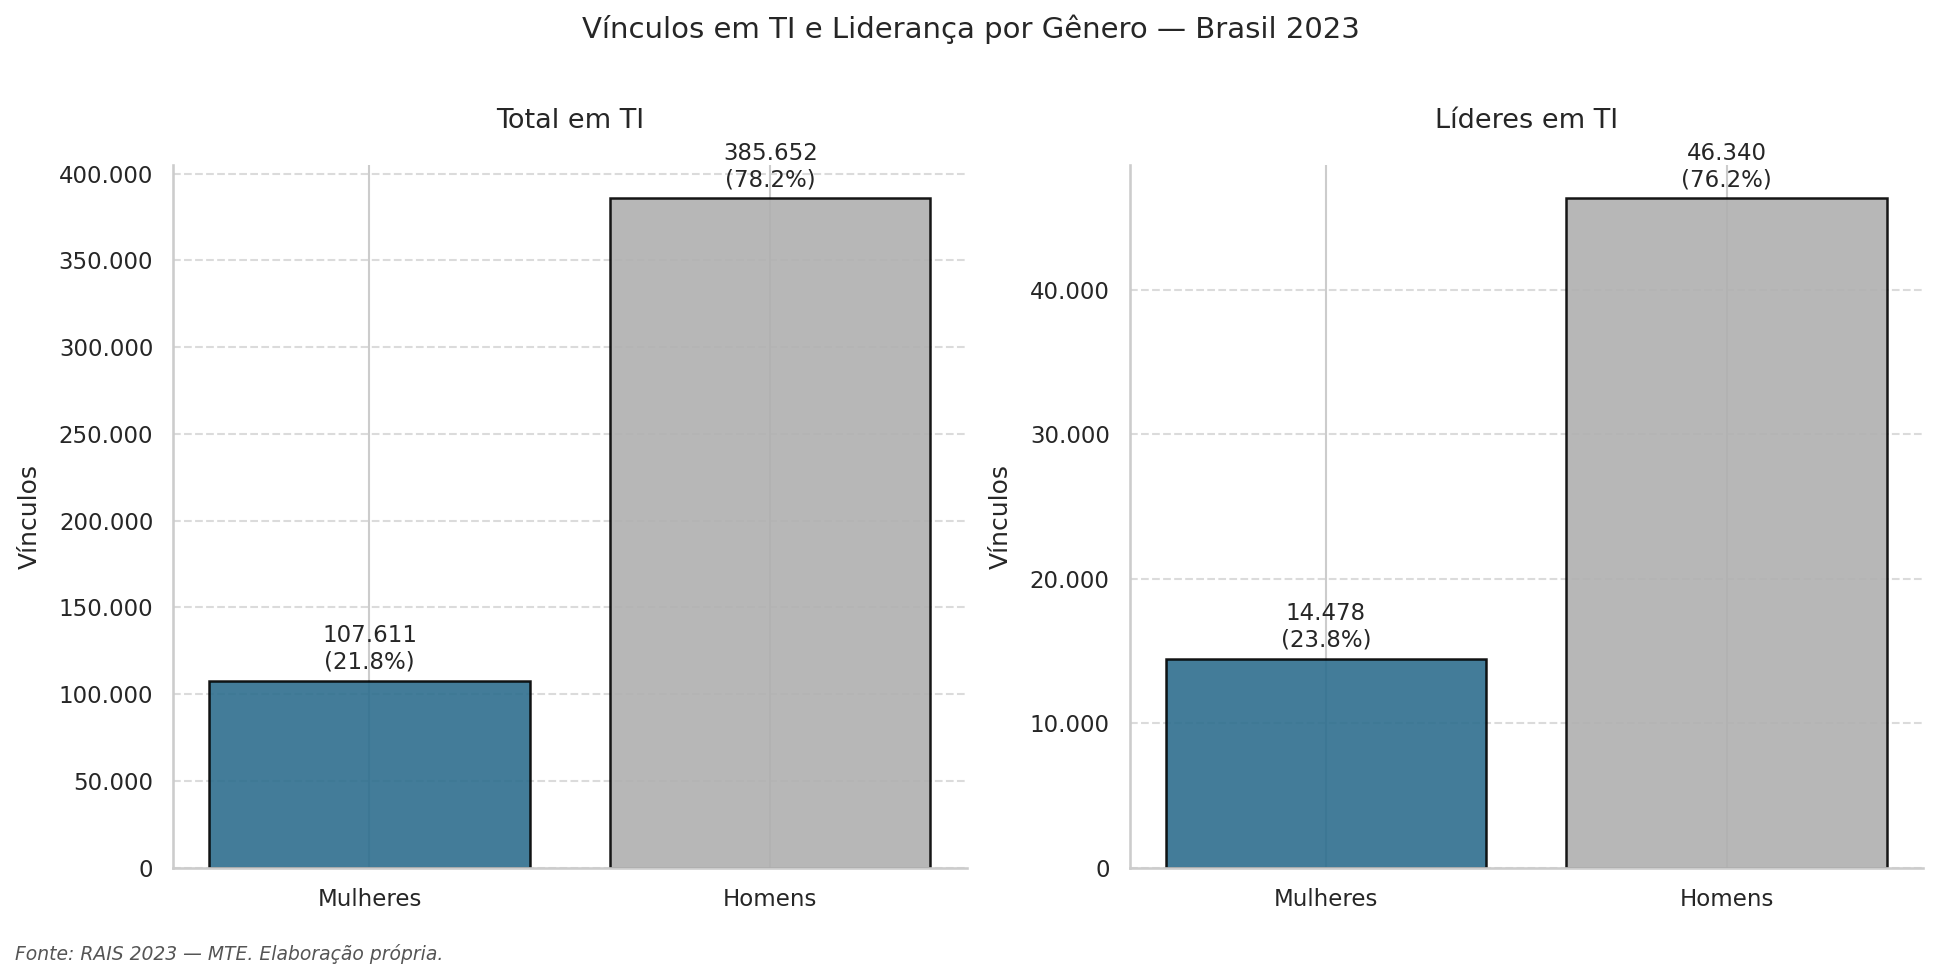

✅ Salvo: /content/outputs/graficos_rais/genero_total_vs_lider.png


/tmp/ipykernel_2882/3455590637.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_raca_rais['Raça'], rotation=30, ha='right')
/tmp/ipykernel_2882/3455590637.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_raca_rais['Raça'], rotation=30, ha='right')


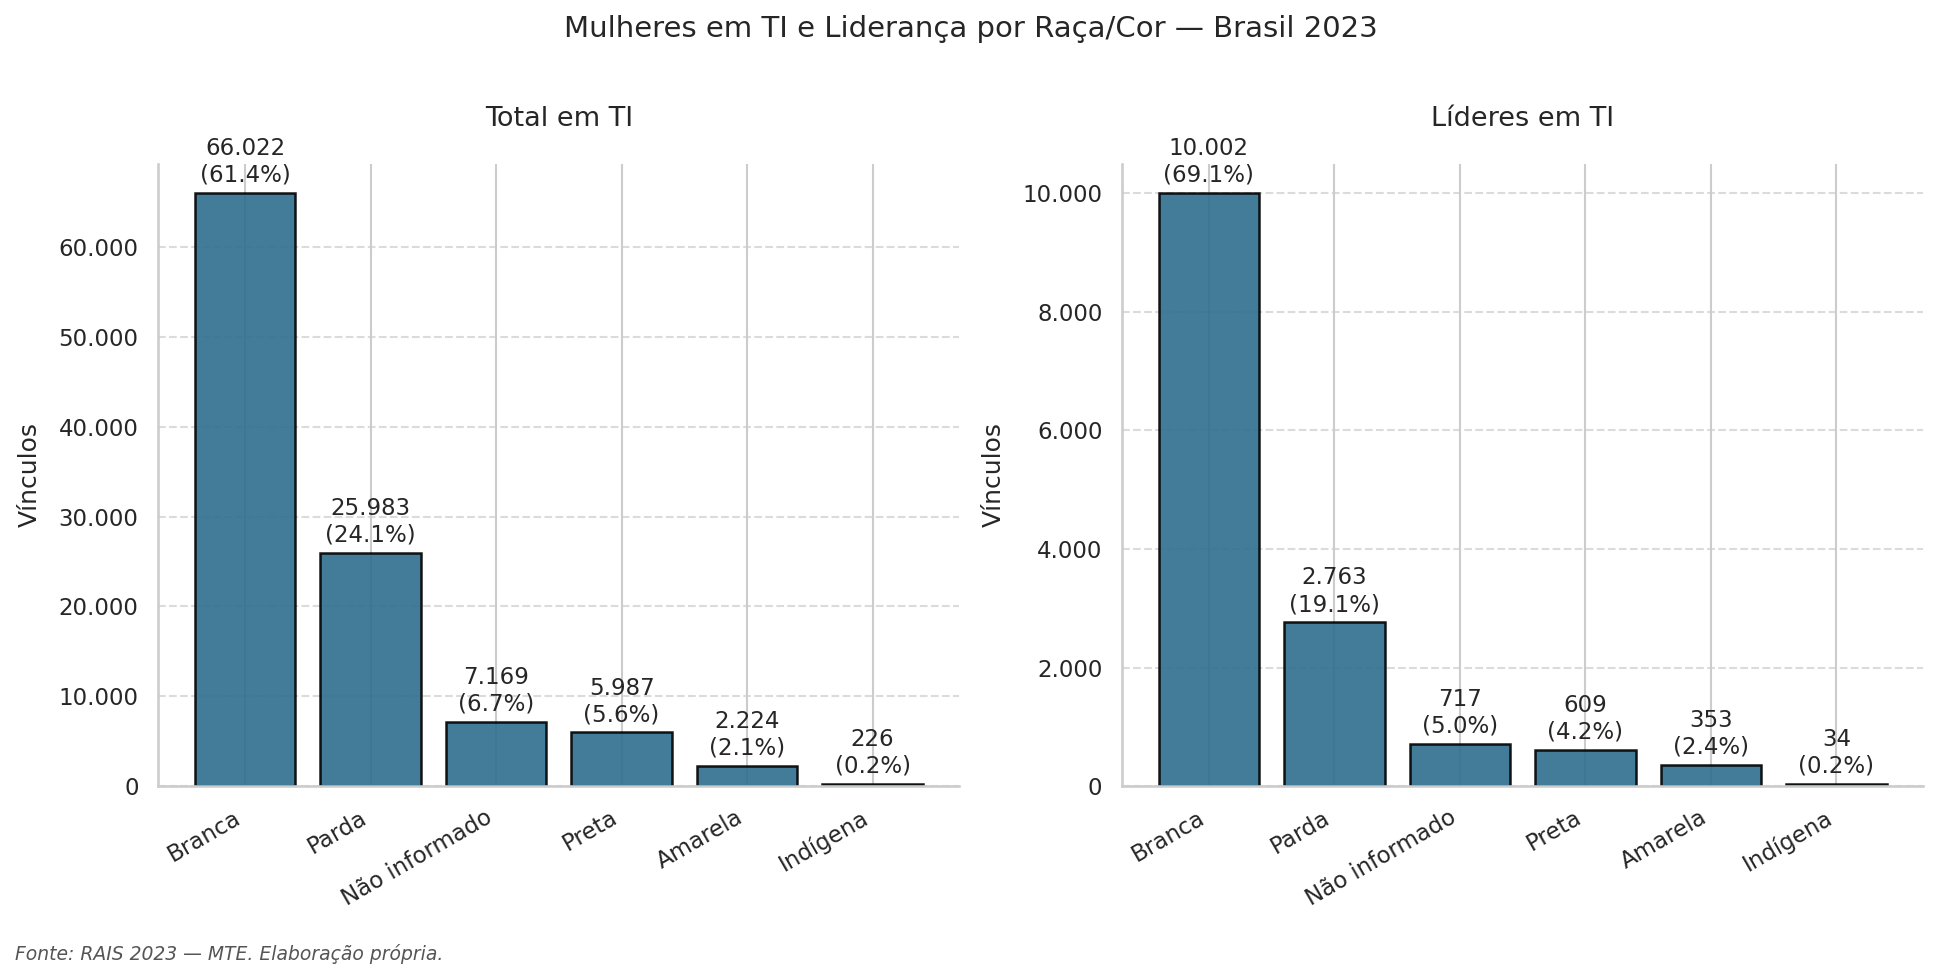

✅ Salvo: /content/outputs/graficos_rais/raca_base_vs_lider.png


/tmp/ipykernel_2882/3455590637.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_escolar_rais['Escolaridade_label'], rotation=40, ha='right')
/tmp/ipykernel_2882/3455590637.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_escolar_rais['Escolaridade_label'], rotation=40, ha='right')


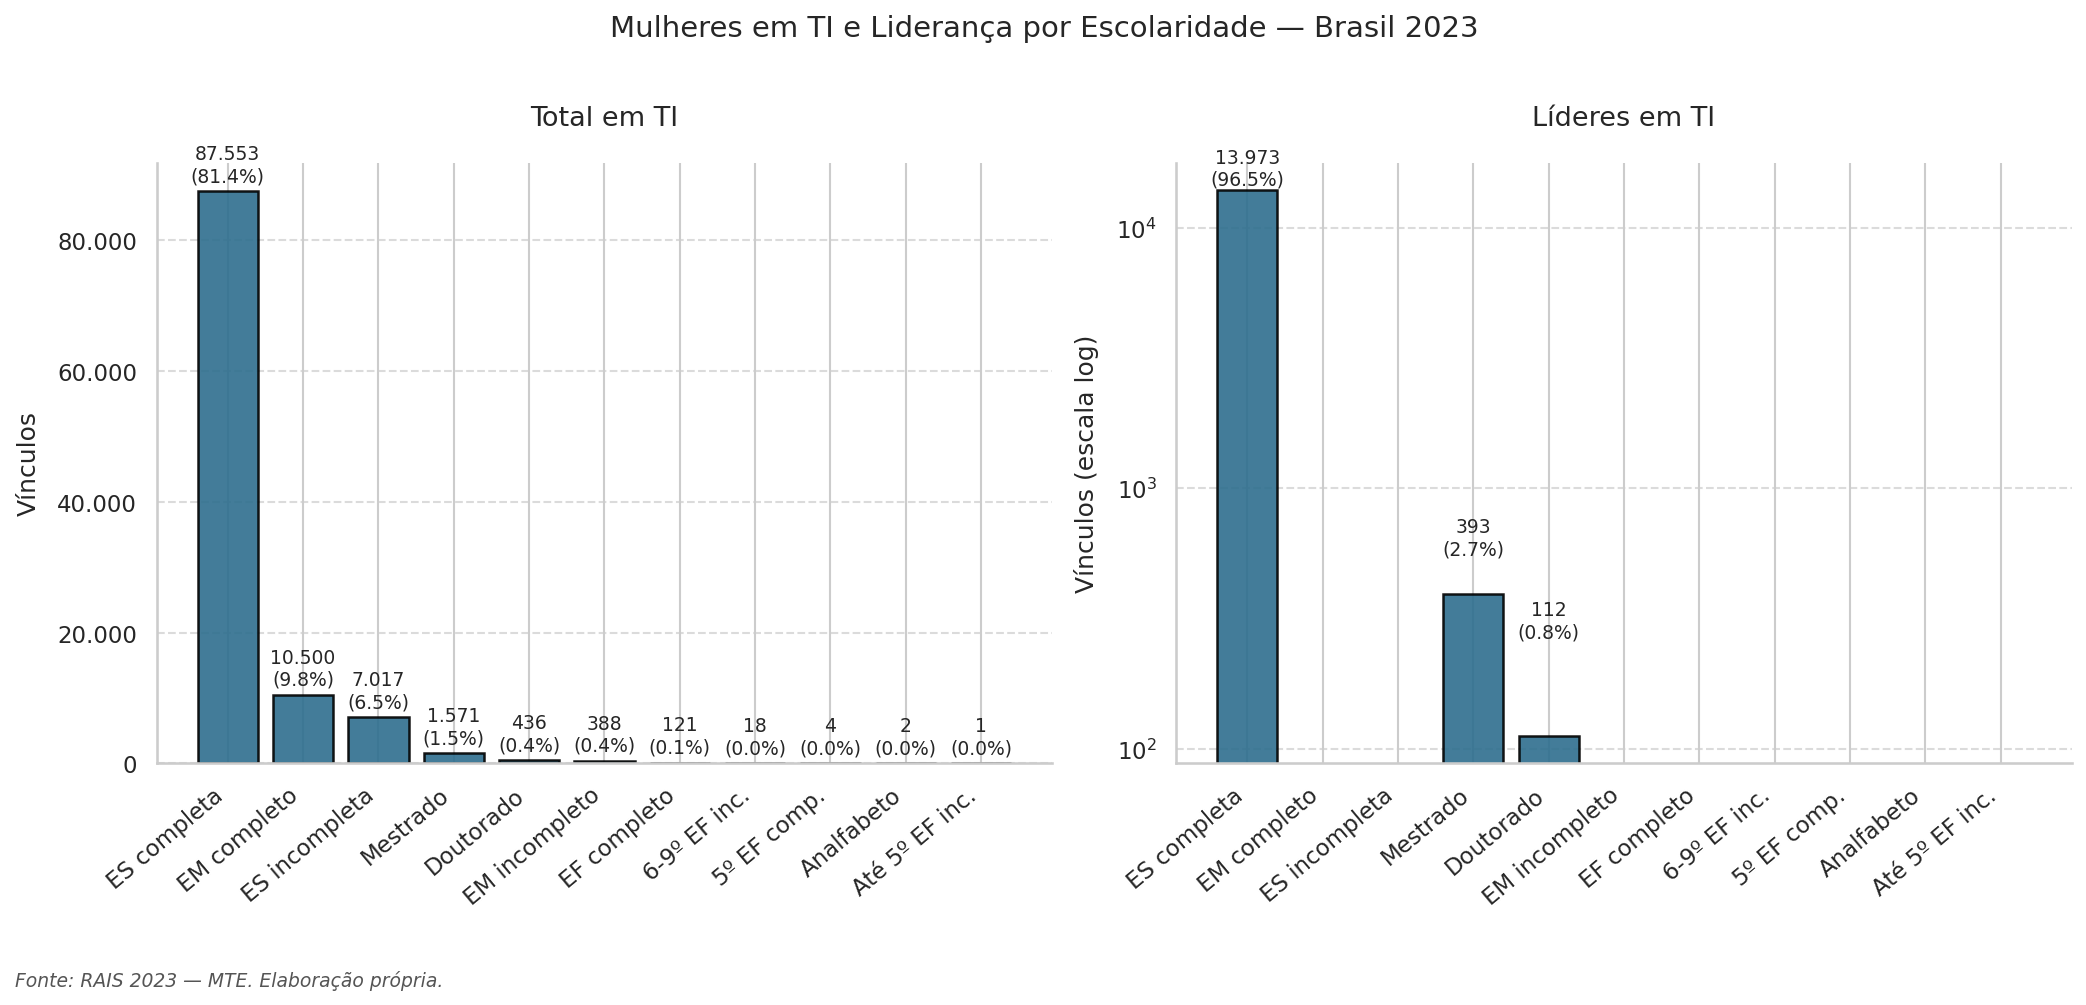

✅ Salvo: /content/outputs/graficos_rais/escolaridade_base_vs_lider.png


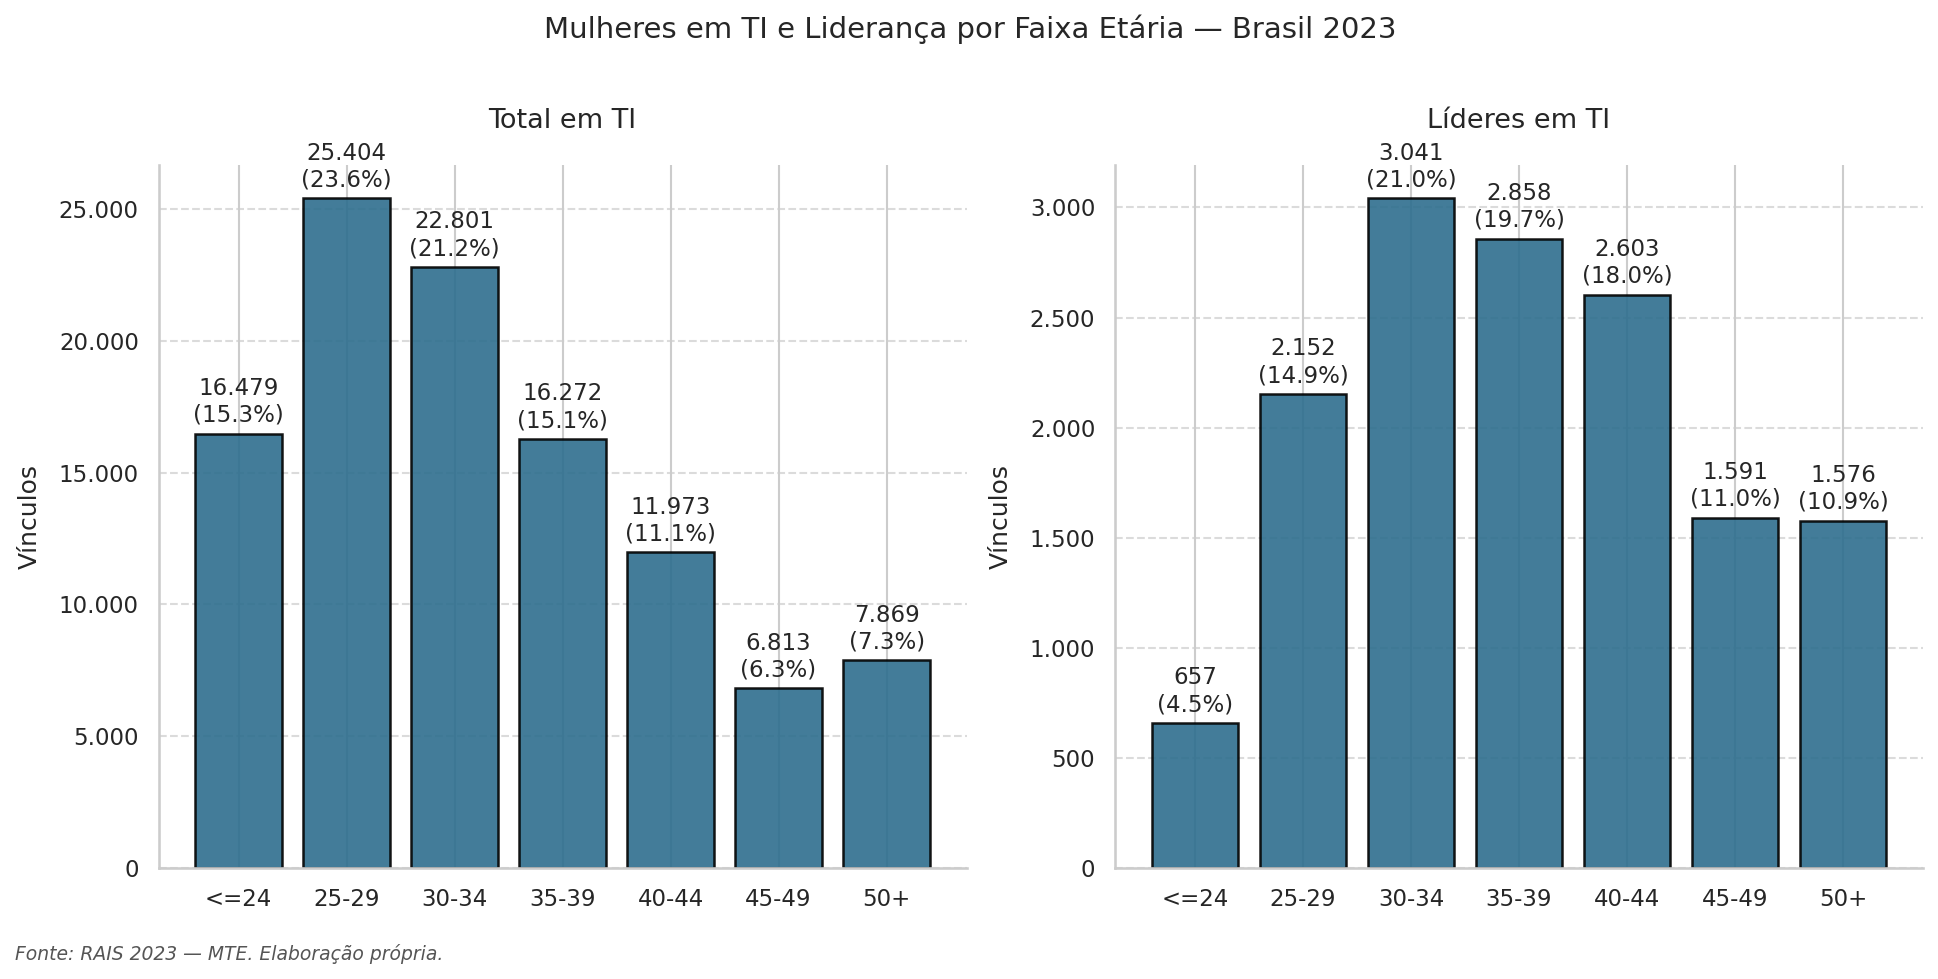

✅ Salvo: /content/outputs/graficos_rais/idade_base_vs_lider.png


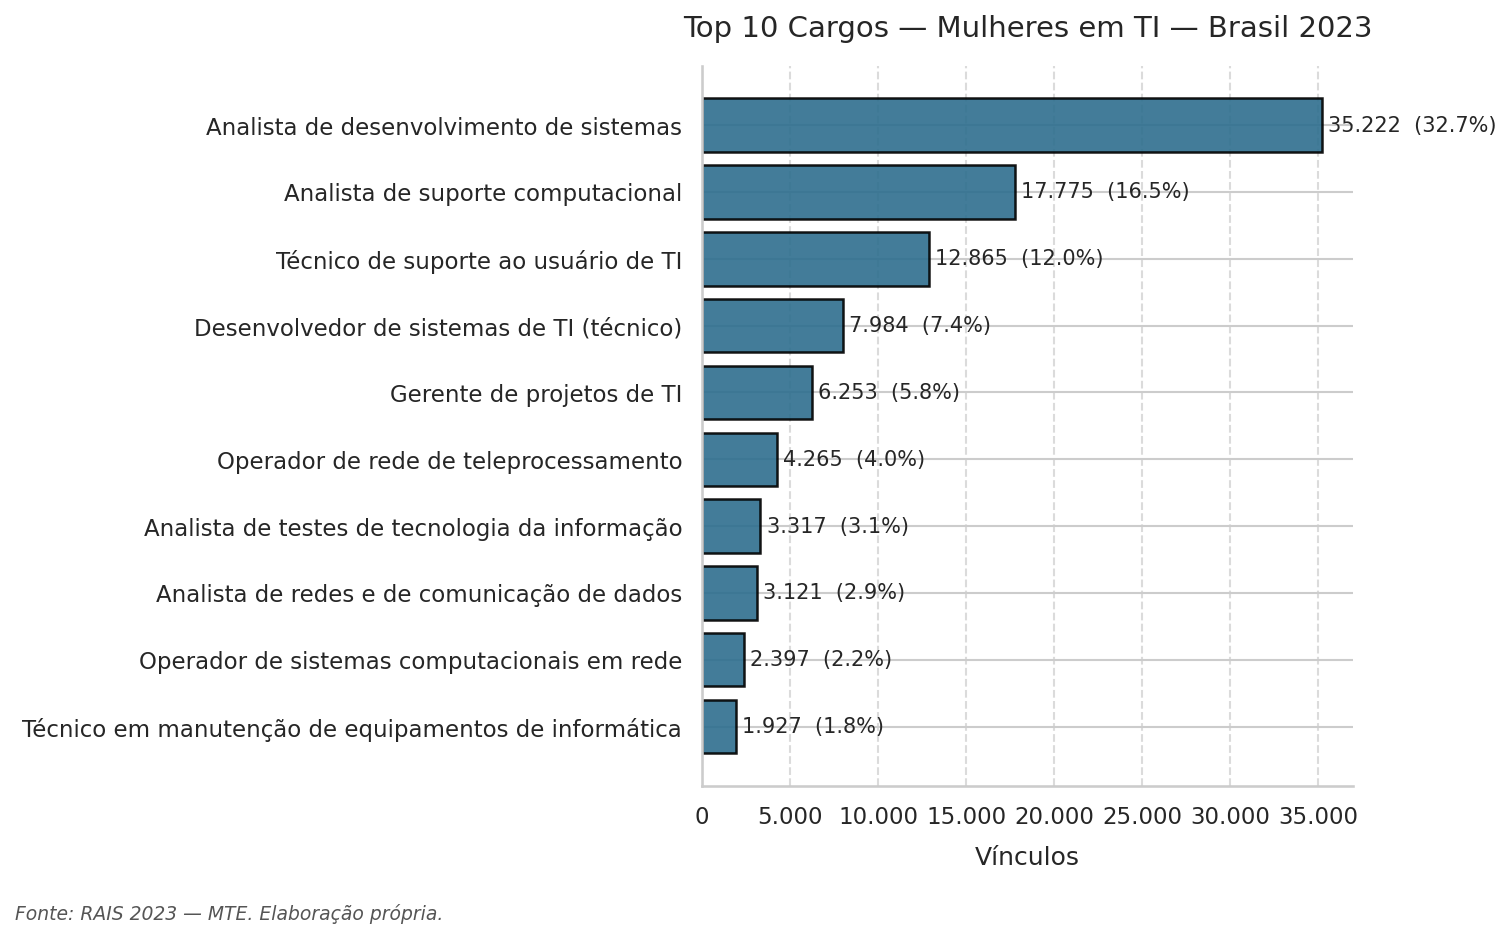

✅ Salvo: /content/outputs/graficos_rais/top10_cargos.png

✅ Todos os gráficos salvos em: /content/outputs/graficos_rais


In [ ]:
import matplotlib.ticker as mticker
import seaborn as sns

ABREV_ESCOLAR = {
    'Analfabeto':                      'Analfabeto',
    'Até 5º ano EF incompleto':        'Até 5º EF inc.',
    '5º ano EF completo':              '5º EF comp.',
    '6º-9º EF incompleto':             '6-9º EF inc.',
    'Ensino Fundamental completo':     'EF completo',
    'Ensino Médio incompleto':         'EM incompleto',
    'Ensino Médio completo':           'EM completo',
    'Educação Superior incompleta':    'ES incompleta',
    'Educação Superior completa':      'ES completa',
    'Mestrado completo':               'Mestrado',
    'Doutorado completo':              'Doutorado',
}
df_escolar_rais['Escolaridade_label'] = (
    df_escolar_rais['Escolaridade']
    .map(ABREV_ESCOLAR)
    .fillna(df_escolar_rais['Escolaridade'])
)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 150})

COR_BASE  = '#2E6E8E'
COR_LIDER = '#2B4C7E'
COR_HOM   = '#b0b0b0'

GRAF_DIR = os.path.join(OUTPUT_DIR, 'graficos_rais')
os.makedirs(GRAF_DIR, exist_ok=True)
FONTE = f'RAIS {ANO_RAIS} — MTE. Elaboração própria.'


def save_fig(fname):
    path = os.path.join(GRAF_DIR, fname)
    plt.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print('✅ Salvo:', path)


def fmt_mil(x, _):
    return f'{int(x):,}'.replace(',', '.')


def _add_bar_labels(ax, bars, total=None, fontsize=11):
    for bar in bars:
        h = bar.get_height()
        if h <= 0:
            continue
        label = f'{int(h):,}'.replace(',', '.')
        if total:
            label += f'\n({h/total*100:.1f}%)'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + ax.get_ylim()[1] * 0.01,
            label, ha='center', va='bottom', fontsize=fontsize,
        )


# 1. Gênero
total_geral = tot_mulheres_ti + tot_homens_ti
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f'Vínculos em TI e Liderança por Gênero — Brasil {ANO_RAIS}', fontsize=14, y=1.02)
for ax, vals, titulo, total in [
    (axes[0], [tot_mulheres_ti, tot_homens_ti],   'Total em TI',   total_geral),
    (axes[1], [tot_mulheres_lid, tot_homens_lid],  'Líderes em TI', total_lid),
]:
    bars = ax.bar(['Mulheres', 'Homens'], vals, color=[COR_BASE, COR_HOM], edgecolor='black', linewidth=1.2, alpha=0.9)
    _add_bar_labels(ax, bars, total=total)
    ax.set_title(titulo, fontsize=13, pad=18)
    ax.set_ylabel('Vínculos', labelpad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
    ax.grid(axis='y', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
fig.text(0.01, -0.03, f'Fonte: {FONTE}', fontsize=9, color='#555555', style='italic')
plt.tight_layout(); save_fig('genero_total_vs_lider.png')


# 2. Raça
if not df_raca_rais.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(f'Mulheres em TI e Liderança por Raça/Cor — Brasil {ANO_RAIS}', fontsize=14, y=1.02)
    for ax, col, titulo, total in [
        (axes[0], 'Qtd',     'Total em TI',   tot_mulheres_ti),
        (axes[1], 'Líderes', 'Líderes em TI', int(df_raca_rais['Líderes'].sum())),
    ]:
        bars = ax.bar(df_raca_rais['Raça'], df_raca_rais[col], color=COR_BASE, edgecolor='black', linewidth=1.2, alpha=0.9)
        _add_bar_labels(ax, bars, total=total)
        ax.set_title(titulo, fontsize=13, pad=18); ax.set_ylabel('Vínculos', labelpad=8)
        ax.set_xticklabels(df_raca_rais['Raça'], rotation=30, ha='right')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
        ax.grid(axis='y', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
    fig.text(0.01, -0.03, f'Fonte: {FONTE}', fontsize=9, color='#555555', style='italic')
    plt.tight_layout(); save_fig('raca_base_vs_lider.png')


# 3. Escolaridade
if not df_escolar_rais.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Mulheres em TI e Liderança por Escolaridade — Brasil {ANO_RAIS}', fontsize=14, y=1.02)
    for ax, col, titulo, total in [
        (axes[0], 'Qtd',     'Total em TI',   tot_mulheres_ti),
        (axes[1], 'Líderes', 'Líderes em TI', int(df_escolar_rais['Líderes'].sum())),
    ]:
        bars = ax.bar(df_escolar_rais['Escolaridade_label'], df_escolar_rais[col], color=COR_BASE, edgecolor='black', linewidth=1.2, alpha=0.9)
        _add_bar_labels(ax, bars, total=total, fontsize=9)
        ax.set_title(titulo, fontsize=13, pad=18); ax.set_ylabel('Vínculos', labelpad=8)
        ax.set_xticklabels(df_escolar_rais['Escolaridade_label'], rotation=40, ha='right')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
        if col == 'Líderes':
            ax.set_yscale('log')
            ax.set_ylabel('Vínculos (escala log)', labelpad=8)
        ax.grid(axis='y', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
    fig.text(0.01, -0.06, f'Fonte: {FONTE}', fontsize=9, color='#555555', style='italic')
    plt.tight_layout(); save_fig('escolaridade_base_vs_lider.png')


# 4. Faixa etária
if not df_idade_rais.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(f'Mulheres em TI e Liderança por Faixa Etária — Brasil {ANO_RAIS}', fontsize=14, y=1.02)
    for ax, col, titulo, total in [
        (axes[0], 'Qtd',     'Total em TI',   tot_mulheres_ti),
        (axes[1], 'Líderes', 'Líderes em TI', int(df_idade_rais['Líderes'].sum())),
    ]:
        bars = ax.bar(df_idade_rais['Faixa'].astype(str), df_idade_rais[col], color=COR_BASE, edgecolor='black', linewidth=1.2, alpha=0.9)
        _add_bar_labels(ax, bars, total=total)
        ax.set_title(titulo, fontsize=13, pad=18); ax.set_ylabel('Vínculos', labelpad=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
        ax.grid(axis='y', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
    fig.text(0.01, -0.03, f'Fonte: {FONTE}', fontsize=9, color='#555555', style='italic')
    plt.tight_layout(); save_fig('idade_base_vs_lider.png')


# 5. Top 10 cargos
if not top_cargos_rais.empty:
    top10 = top_cargos_rais.head(10).copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top10['Cargo'], top10['Qtd'], color=COR_BASE, edgecolor='black', linewidth=1.2, alpha=0.9)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + top10['Qtd'].max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{int(w):,}'.replace(',','.')+ f'  ({w/tot_mulheres_ti*100:.1f}%)', va='center', fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Vínculos', labelpad=8)
    ax.set_title(f'Top 10 Cargos — Mulheres em TI — Brasil {ANO_RAIS}', fontsize=14, pad=14)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
    ax.grid(axis='x', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
    fig.text(0.01, -0.03, f'Fonte: {FONTE}', fontsize=9, color='#555555', style='italic')
    plt.tight_layout(); save_fig('top10_cargos.png')

print('\n✅ Todos os gráficos salvos em:', GRAF_DIR)


### 2.11 Exportar resultados RAIS para Excel

In [ ]:
!pip install -q xlsxwriter

# Nome do arquivo Excel derivado automaticamente dos arquivos processados
regioes_proc = '_'.join(
    os.path.basename(f).replace('RAIS_VINC_PUB_','').replace('.txt','')
    for f in TXT_FILES
) if len(TXT_FILES) <= 3 else 'brasil'

xl_rais = os.path.join(OUTPUT_DIR, f'rais_{regioes_proc}_{ANO_RAIS}_mulheres_ti.xlsx')


def autosize(ws, df, max_w=50, min_w=8):
    for i, col in enumerate(df.columns):
        w = min(max(df[col].astype(str).map(len).max(), len(str(col))) + 2, max_w)
        ws.set_column(i, i, max(w, min_w))


meta = pd.DataFrame([
    ['Gerado em',                 datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    ['Arquivos fonte',            ', '.join(os.path.basename(f) for f in TXT_FILES)],
    ['Somente vínculos ativos?',  str(FILTRAR_ATIVO)],
    ['Total mulheres TI',         tot_mulheres_ti],
    ['Total homens TI',           tot_homens_ti],
    ['Mulheres líderes TI',       tot_mulheres_lid],
], columns=['Campo', 'Valor'])

sheets_rais = {
    '00_Resumo':       meta,
    '01_Genero':       summary_genero,
    '02_Raca':         df_raca_rais,
    '03_Escolaridade': df_escolar_rais,
    '04_Faixa_Etaria': df_idade_rais,
    '05_Top_Cargos':   top_cargos_rais,
}

with pd.ExcelWriter(xl_rais, engine='xlsxwriter') as writer:
    wb = writer.book
    hdr = wb.add_format({'bold': True, 'bg_color': '#F2F2F2', 'border': 1})
    for sname, df in sheets_rais.items():
        df = df.copy()
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='ignore')
        df.to_excel(writer, sheet_name=sname, index=False, startrow=1)
        ws = writer.sheets[sname]
        for ci, cn in enumerate(df.columns):
            ws.write(0, ci, cn, hdr)
        ws.freeze_panes(1, 0)
        autosize(ws, df)

print(f'✅ Excel RAIS gerado: {xl_rais}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 16.3 MB/s eta 0:00:00
✅ Excel RAIS gerado: /content/outputs/rais_brasil_2023_mulheres_ti.xlsx


/tmp/ipykernel_2882/831752459.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/tmp/ipykernel_2882/831752459.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/tmp/ipykernel_2882/831752459.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/tmp/ipykernel_2882/831752459.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/tmp/ipykernel_2

---
## 3. Censo da Educação Superior

### 3.1 Carregar dados

> Ajuste `ANO_CENSO` conforme o arquivo disponível (2023 ou 2024).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ANO_CENSO  = 2023
CENSO_DIR  = '/content/drive/MyDrive/TCC'  # ← ajuste o caminho se necessário

CENSO_CURSOS_PATH = f'{CENSO_DIR}/MICRODADOS_CADASTRO_CURSOS_{ANO_CENSO}.CSV'
CENSO_IES_PATH    = f'{CENSO_DIR}/MICRODADOS_ED_SUP_IES_{ANO_CENSO}.CSV'

def read_censo(path, **kw):
    for enc in ('utf-8', 'latin-1'):
        try:
            return pd.read_csv(path, sep=';', encoding=enc, low_memory=False, **kw)
        except UnicodeDecodeError:
            continue
    raise ValueError(f'Não foi possível ler {path}')

censo_cursos_df = read_censo(CENSO_CURSOS_PATH)
censo_ies_df    = read_censo(CENSO_IES_PATH)

print(f'Cursos {ANO_CENSO}: {censo_cursos_df.shape[0]:,} linhas x {censo_cursos_df.shape[1]} colunas')
print(f'IES    {ANO_CENSO}: {censo_ies_df.shape[0]:,} linhas x {censo_ies_df.shape[1]} colunas')
print(f'UFs disponíveis: {sorted(censo_cursos_df["SG_UF"].unique())}')

### 3.2 Inspeção rápida

In [ ]:
display(censo_cursos_df.head(3))
display(censo_ies_df.head(3))

,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,IN_CAPITAL,TP_DIMENSAO,...,QT_MAT_APOIO_SOCIAL,QT_CONC_APOIO_SOCIAL,QT_ATIV_EXTRACURRICULAR,QT_ING_ATIV_EXTRACURRICULAR,QT_MAT_ATIV_EXTRACURRICULAR,QT_CONC_ATIV_EXTRACURRICULAR,QT_MOB_ACADEMICA,QT_ING_MOB_ACADEMICA,QT_MAT_MOB_ACADEMICA,QT_CONC_MOB_ACADEMICA
0,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
1,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,2,2,2,0,0,0,0,0
2,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0


,NU_ANO_CENSO,NO_REGIAO_IES,CO_REGIAO_IES,NO_UF_IES,SG_UF_IES,CO_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,IN_CAPITAL_IES,NO_MESORREGIAO_IES,...,QT_DOC_EX_60_MAIS,QT_DOC_EX_BRANCA,QT_DOC_EX_PRETA,QT_DOC_EX_PARDA,QT_DOC_EX_AMARELA,QT_DOC_EX_INDIGENA,QT_DOC_EX_COR_ND,QT_DOC_EX_BRA,QT_DOC_EX_EST,QT_DOC_EX_COM_DEFICIENCIA
0,2023,Centro-Oeste,5,Mato Grosso,MT,51,Cuiabá,5103403,1,Centro-Sul Mato-grossense,...,175,1003,85,454,38,6,2,1559,29,12
1,2023,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,1,Distrito Federal,...,548,1958,109,625,66,11,32,2669,132,10
2,2023,Nordeste,2,Sergipe,SE,28,São Cristóvão,2806701,0,Leste Sergipano,...,205,242,36,295,11,1,1183,1739,29,5


### 3.3 Seleção de colunas e filtro de TI (vetorizado)

In [ ]:
COLS_KEEP = [
    'NU_ANO_CENSO','NO_REGIAO','SG_UF','NO_MUNICIPIO','CO_IES',
    'TP_MODALIDADE_ENSINO','TP_REDE','TP_ORGANIZACAO_ACADEMICA',
    'NO_CINE_ROTULO','NO_CINE_AREA_GERAL','NO_CINE_AREA_ESPECIFICA','NO_CINE_AREA_DETALHADA',
    'QT_ING','QT_ING_FEM','QT_ING_MASC',
    'QT_MAT','QT_MAT_FEM','QT_MAT_MASC',
    'QT_CONC','QT_CONC_FEM','QT_CONC_MASC',
    'QT_SIT_TRANCADA','QT_SIT_DESVINCULADO','QT_SIT_TRANSFERIDO','QT_SIT_FALECIDO',
    'QT_ING_FIES','QT_MAT_FIES','QT_CONC_FIES',
    'QT_ING_PROUNII','QT_ING_PROUNIP','QT_MAT_PROUNII','QT_MAT_PROUNIP',
    'QT_ING_APOIO_SOCIAL','QT_MAT_APOIO_SOCIAL','QT_CONC_APOIO_SOCIAL',
    'QT_ING_RESERVA_VAGA','QT_MAT_RESERVA_VAGA','QT_CONC_RESERVA_VAGA',
]
cols_existentes = [c for c in COLS_KEEP if c in censo_cursos_df.columns]
censo_df = censo_cursos_df[cols_existentes].copy()

num_cols = [c for c in censo_df.columns if c.startswith('QT_')]
for c in num_cols:
    censo_df[c] = pd.to_numeric(censo_df[c], errors='coerce').fillna(0)

# Filtro de TI vetorizado (sem apply linha a linha)
TI_TERMS = [
    'computação','ciência da computação','engenharia de computação',
    'sistemas de informação','análise e desenvolvimento de sistemas',
    'redes de computadores','segurança da informação','banco de dados',
    'informática','jogos digitais','engenharia de software','tecnologia da informação',
]
ti_pattern = '|'.join(TI_TERMS)

texto_ti = (
    censo_df['NO_CINE_ROTULO'].fillna('') + ' ' +
    censo_df['NO_CINE_AREA_DETALHADA'].fillna('') + ' ' +
    censo_df['NO_CINE_AREA_ESPECIFICA'].fillna('') + ' ' +
    censo_df['NO_CINE_AREA_GERAL'].fillna('')
).str.lower()

ti_censo = censo_df.loc[texto_ti.str.contains(ti_pattern, regex=True, na=False)].copy()
print(f'Cursos de TI: {len(ti_censo):,} de {len(censo_df):,} total')
print('Cursos únicos:', ti_censo['NO_CINE_ROTULO'].nunique())


Cursos de TI: 71,426 de 671,610 total
Cursos únicos: 22


### 3.4 Join com IES (categoria administrativa)

In [ ]:
cols_ies = ['CO_IES','TP_CATEGORIA_ADMINISTRATIVA','TP_ORGANIZACAO_ACADEMICA','NO_IES']
cols_ies_exist = [c for c in cols_ies if c in censo_ies_df.columns]

ti_censo = ti_censo.merge(
    censo_ies_df[cols_ies_exist].drop_duplicates('CO_IES'),
    on='CO_IES', how='left', suffixes=('', '_ies'),
)
print(f'Shape após join com IES: {ti_censo.shape}')
if 'TP_CATEGORIA_ADMINISTRATIVA' in ti_censo.columns:
    print('Categorias administrativas:', ti_censo['TP_CATEGORIA_ADMINISTRATIVA'].value_counts().to_dict())


Shape após join com IES: (71426, 41)
Categorias administrativas: {4: 62926, 5: 6553, 2: 1061, 1: 818, 7: 44, 3: 24}


### 3.5 Indicadores por UF / modalidade

In [ ]:
GRP = ['NU_ANO_CENSO','SG_UF','TP_MODALIDADE_ENSINO']
agg = ti_censo.groupby(GRP, dropna=False).sum(numeric_only=True).reset_index()

agg['part_fem_ing']  = (100 * safe_div(agg['QT_ING_FEM'],  agg['QT_ING'])).round(2)
agg['part_fem_mat']  = (100 * safe_div(agg['QT_MAT_FEM'],  agg['QT_MAT'])).round(2)
agg['part_fem_conc'] = (100 * safe_div(agg['QT_CONC_FEM'], agg['QT_CONC'])).round(2)

den = agg['QT_MAT'].replace(0, np.nan)
agg['evasao']         = (100 * safe_div(agg['QT_SIT_DESVINCULADO'], den)).round(2)
agg['tranc']          = (100 * safe_div(agg['QT_SIT_TRANCADA'],     den)).round(2)
agg['transf']         = (100 * safe_div(agg['QT_SIT_TRANSFERIDO'],  den)).round(2)
agg['conc_sobre_ing'] = (100 * safe_div(agg['QT_CONC'], agg['QT_ING'])).round(2)

ultimo_ano = int(agg['NU_ANO_CENSO'].max())
painel = agg.loc[agg['NU_ANO_CENSO'].eq(ultimo_ano)].sort_values('SG_UF').reset_index(drop=True)

print(f'Indicadores TI — {ultimo_ano}')
display(painel[[
    'SG_UF','TP_MODALIDADE_ENSINO',
    'QT_ING','QT_ING_FEM','QT_MAT','QT_MAT_FEM','QT_CONC','QT_CONC_FEM',
    'part_fem_ing','part_fem_mat','part_fem_conc','evasao','tranc','transf','conc_sobre_ing'
]].head(30))


Indicadores TI — 2023


,SG_UF,TP_MODALIDADE_ENSINO,QT_ING,QT_ING_FEM,QT_MAT,QT_MAT_FEM,QT_CONC,QT_CONC_FEM,part_fem_ing,part_fem_mat,part_fem_conc,evasao,tranc,transf,conc_sobre_ing
0,AC,1,242,46,554,92,52,6,19.01,16.61,11.54,32.67,14.26,0.00,21.49
1,AC,2,638,108,864,129,100,12,16.93,14.93,12.00,44.10,31.37,1.16,15.67
2,AL,1,922,130,2689,385,200,20,14.10,14.32,10.00,22.72,11.57,0.48,21.69
3,AL,2,2321,347,2663,404,210,23,14.95,15.17,10.95,47.28,32.78,1.05,9.05
4,AM,1,2803,606,7088,1473,453,102,21.62,20.78,22.52,13.98,23.53,0.78,16.16
5,AM,2,5192,1114,5967,1210,412,58,21.46,20.28,14.08,43.34,38.91,1.17,7.94
6,AP,1,331,55,876,128,74,10,16.62,14.61,13.51,40.98,13.13,0.57,22.36
7,AP,2,908,164,1149,209,109,16,18.06,18.19,14.68,52.22,35.42,1.48,12.00
8,BA,1,3924,627,10385,1585,684,100,15.98,15.26,14.62,22.83,9.88,0.85,17.43
9,BA,2,11061,2134,13947,2446,1927,286,19.29,17.54,14.84,45.64,28.31,1.41,17.42


### 3.6 Indicadores por curso

In [ ]:
GRP_CURSO = ['NU_ANO_CENSO','SG_UF','TP_MODALIDADE_ENSINO','NO_CINE_ROTULO']
agg_curso = ti_censo.groupby(GRP_CURSO, dropna=False).sum(numeric_only=True).reset_index()

for prefix in ['ING','MAT','CONC']:
    total = agg_curso[f'QT_{prefix}'].replace(0, np.nan)
    agg_curso[f'part_fem_{prefix.lower()}']  = (100 * safe_div(agg_curso[f'QT_{prefix}_FEM'],  total)).round(2)
    agg_curso[f'part_masc_{prefix.lower()}'] = (100 * safe_div(agg_curso[f'QT_{prefix}_MASC'], total)).round(2)

agg_curso['conc_sobre_ing_fem']  = (100 * safe_div(agg_curso['QT_CONC_FEM'],  agg_curso['QT_ING_FEM'])).round(2)
agg_curso['conc_sobre_ing_masc'] = (100 * safe_div(agg_curso['QT_CONC_MASC'], agg_curso['QT_ING_MASC'])).round(2)

den2 = agg_curso['QT_MAT'].replace(0, np.nan)
agg_curso['evasao'] = (100 * safe_div(agg_curso['QT_SIT_DESVINCULADO'], den2)).round(2)
agg_curso['tranc']  = (100 * safe_div(agg_curso['QT_SIT_TRANCADA'],     den2)).round(2)
agg_curso['transf'] = (100 * safe_div(agg_curso['QT_SIT_TRANSFERIDO'],  den2)).round(2)

painel_curso = (
    agg_curso.loc[agg_curso['NU_ANO_CENSO'].eq(ultimo_ano)]
    .sort_values(['NO_CINE_ROTULO','SG_UF'])
    .reset_index(drop=True)
)
print(f'Indicadores por Curso — TI — {ultimo_ano}')
display(painel_curso.head(20))


Indicadores por Curso — TI — 2023


,NU_ANO_CENSO,SG_UF,TP_MODALIDADE_ENSINO,NO_CINE_ROTULO,CO_IES,TP_REDE,TP_ORGANIZACAO_ACADEMICA,QT_ING,QT_ING_FEM,QT_ING_MASC,...,part_masc_ing,part_fem_mat,part_masc_mat,part_fem_conc,part_masc_conc,conc_sobre_ing_fem,conc_sobre_ing_masc,evasao,tranc,transf
0,2023,BA,1,ABI Computação e Tecnologias da Informação e C...,599,1,4,0,0,0,...,NaN,30.00,70.00,NaN,NaN,NaN,NaN,10.00,1.67,3.33
1,2023,DF,1,ABI Computação e Tecnologias da Informação e C...,14408,1,4,64,11,53,...,82.81,22.22,77.78,NaN,NaN,0.0,0.00,49.21,12.70,12.70
2,2023,AC,2,Agrocomputação,7695,6,6,3,0,3,...,100.00,0.00,100.00,NaN,NaN,NaN,0.00,0.00,0.00,0.00
3,2023,AL,2,Agrocomputação,17197,10,10,7,0,7,...,100.00,0.00,100.00,NaN,NaN,NaN,0.00,25.00,0.00,0.00
4,2023,AM,2,Agrocomputação,8832,12,12,5,2,3,...,60.00,28.57,71.43,NaN,NaN,0.0,0.00,28.57,0.00,0.00
5,2023,AP,2,Agrocomputação,4416,6,6,4,1,3,...,75.00,20.00,80.00,NaN,NaN,0.0,0.00,40.00,0.00,0.00
6,2023,BA,2,Agrocomputação,75610,76,76,36,7,29,...,80.56,23.64,76.36,NaN,NaN,0.0,0.00,30.91,0.00,3.64
7,2023,CE,2,Agrocomputação,35998,40,40,10,4,6,...,60.00,33.33,66.67,NaN,NaN,0.0,0.00,73.33,0.00,0.00
8,2023,DF,2,Agrocomputação,6223,4,4,4,2,2,...,50.00,25.00,75.00,NaN,NaN,0.0,0.00,37.50,0.00,0.00
9,2023,ES,2,Agrocomputação,5888,8,8,1,1,0,...,0.00,100.00,0.00,NaN,NaN,0.0,NaN,150.00,0.00,0.00


### 3.7 Distribuição racial (Censo)

In [ ]:
# painel_raca_censo — nome distinto para não colidir com df_raca_rais (RAIS)
COLS_RACA_CENSO = [
    'QT_ING_BRANCA','QT_ING_PRETA','QT_ING_PARDA','QT_ING_AMARELA','QT_ING_INDIGENA','QT_ING_CORND',
    'QT_MAT_BRANCA','QT_MAT_PRETA','QT_MAT_PARDA','QT_MAT_AMARELA','QT_MAT_INDIGENA','QT_MAT_CORND',
    'QT_CONC_BRANCA','QT_CONC_PRETA','QT_CONC_PARDA','QT_CONC_AMARELA','QT_CONC_INDIGENA','QT_CONC_CORND',
    'QT_ING','QT_MAT','QT_CONC',
]
cols_raca_exist = [c for c in COLS_RACA_CENSO if c in ti_censo.columns]
raca_df = ti_censo[['NU_ANO_CENSO','SG_UF','NO_CINE_ROTULO'] + cols_raca_exist].copy()

GRP_R = ['NU_ANO_CENSO','SG_UF','NO_CINE_ROTULO']
agg_raca_censo = raca_df.groupby(GRP_R, dropna=False).sum(numeric_only=True).reset_index()

for prefix in ['QT_ING','QT_MAT','QT_CONC']:
    total_r = agg_raca_censo[prefix].replace(0, np.nan)
    for grupo in ['BRANCA','PRETA','PARDA','AMARELA','INDIGENA','CORND']:
        col = f'{prefix}_{grupo}'
        if col in agg_raca_censo.columns:
            suffix = prefix.split('_')[1].lower()
            agg_raca_censo[f'part_{grupo.lower()}_{suffix}'] = (
                100 * safe_div(agg_raca_censo[col], total_r)
            ).round(2)

painel_raca_censo = agg_raca_censo.loc[agg_raca_censo['NU_ANO_CENSO'].eq(ultimo_ano)].reset_index(drop=True)
pct_conc = [c for c in painel_raca_censo.columns if 'conc' in c and c.startswith('part_')]
print(f'Distribuição racial — TI — {ultimo_ano}')
display(painel_raca_censo[['SG_UF','NO_CINE_ROTULO'] + pct_conc].head(20))


Distribuição racial — TI — 2023


,SG_UF,NO_CINE_ROTULO
0,AC,Agrocomputação
1,AC,Banco de dados
2,AC,Ciência da computação
3,AC,Ciência de dados
4,AC,Computação formação de professor
5,AC,Defesa cibernética
6,AC,Engenharia de computação (DCN Computação)
7,AC,Engenharia de computação (DCN Engenharia)
8,AC,Engenharia de software
9,AC,Gestão da tecnologia da informação


### 3.8 Exportar Censo para Excel

In [ ]:
xl_censo = os.path.join(OUTPUT_DIR, f'censo_ed_sup_ti_{ANO_CENSO}.xlsx')

sheets_censo = {
    '00_Resumo_Geral': painel,
    '01_Por_Curso':    painel_curso,
    '02_Por_Raca':     painel_raca_censo,
}

with pd.ExcelWriter(xl_censo, engine='openpyxl') as writer:
    for sname, df in sheets_censo.items():
        df.to_excel(writer, sheet_name=sname, index=False)

print(f'✅ Excel Censo gerado: {xl_censo}')


✅ Excel Censo gerado: /content/outputs/censo_ed_sup_ti_2023.xlsx


### 3.9 Gráficos Censo Ensino Superior

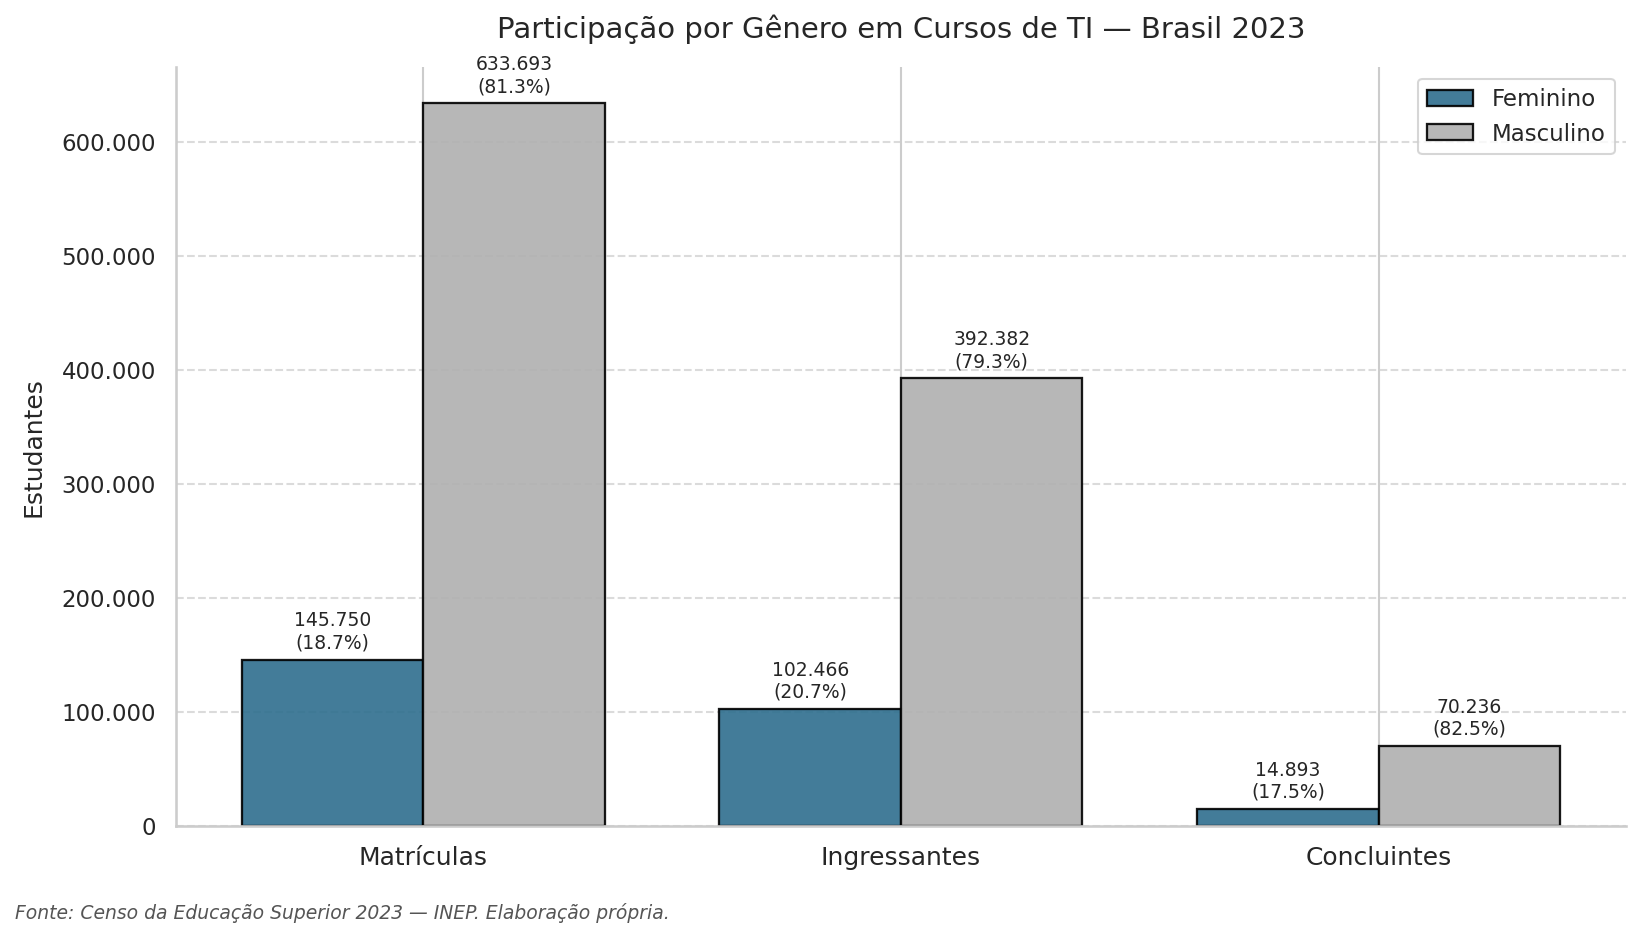

✅ Salvo: /content/outputs/graficos_censo/participacao_genero_ti.png


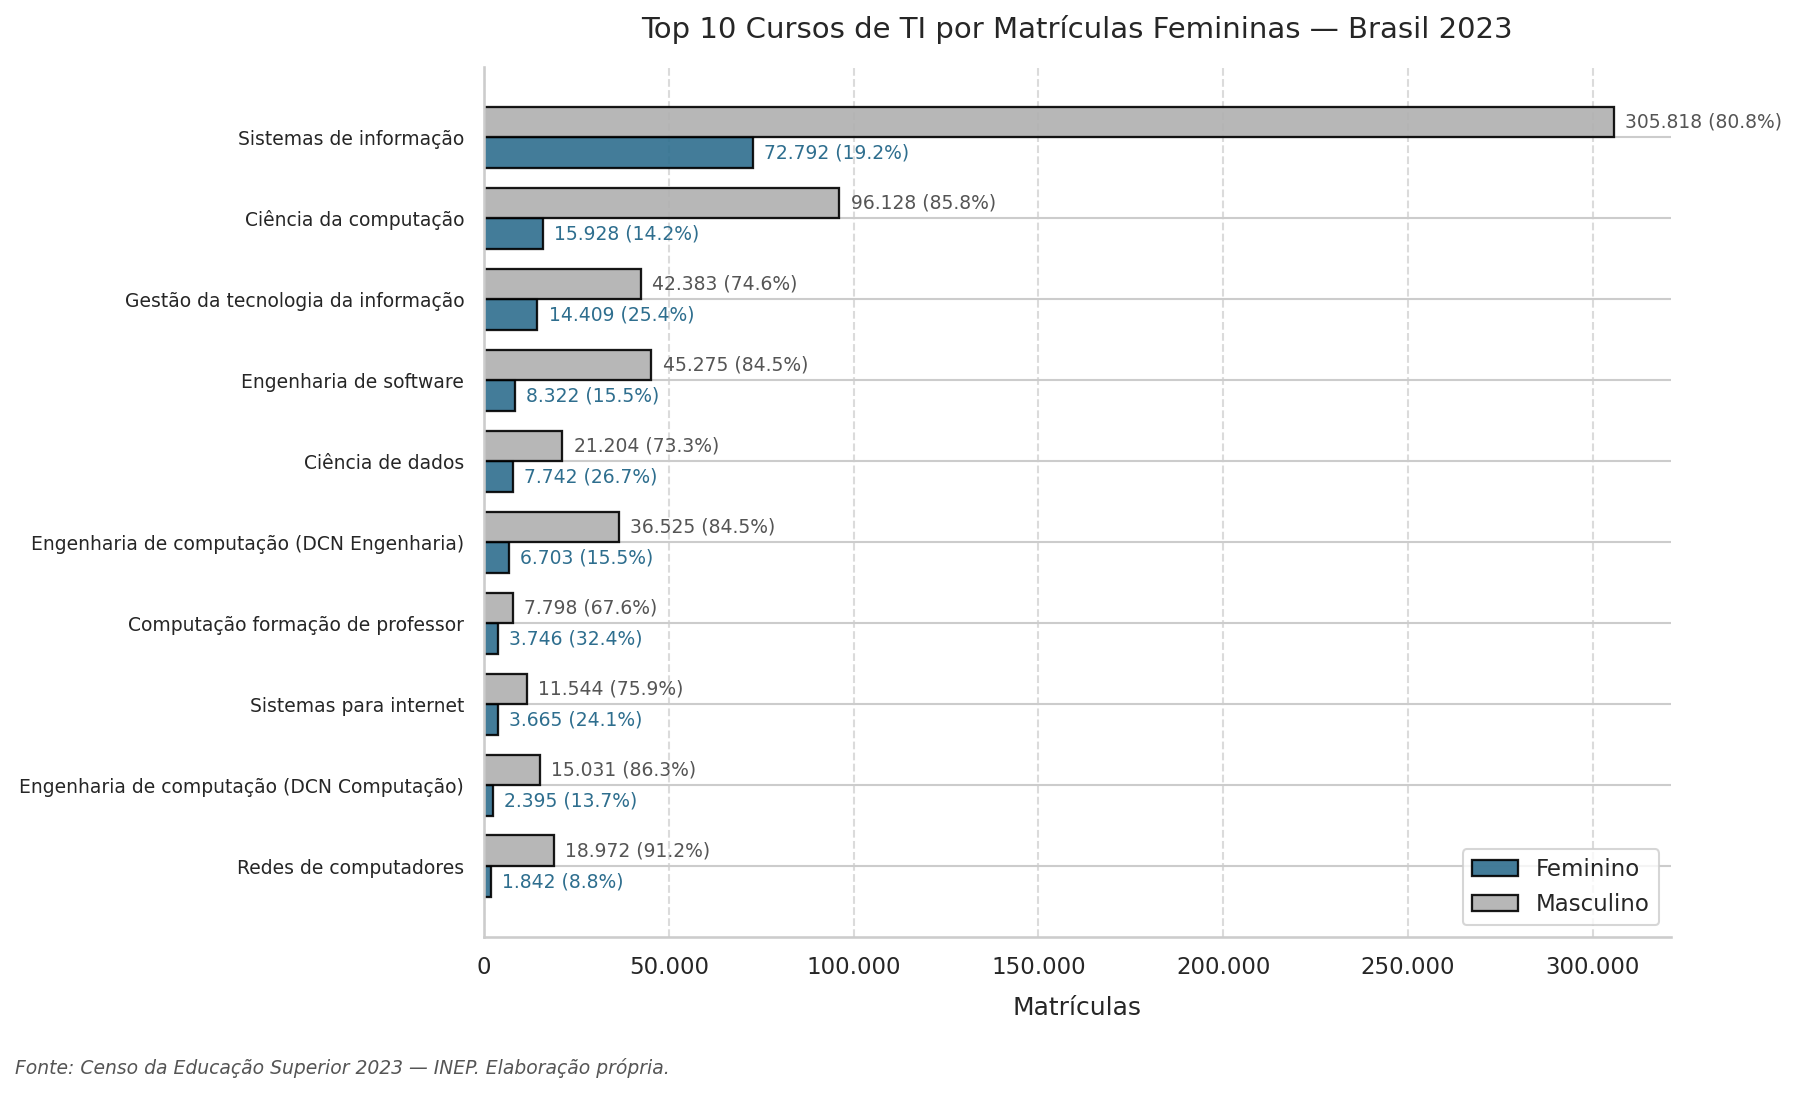

✅ Salvo: /content/outputs/graficos_censo/top10_cursos_ti.png


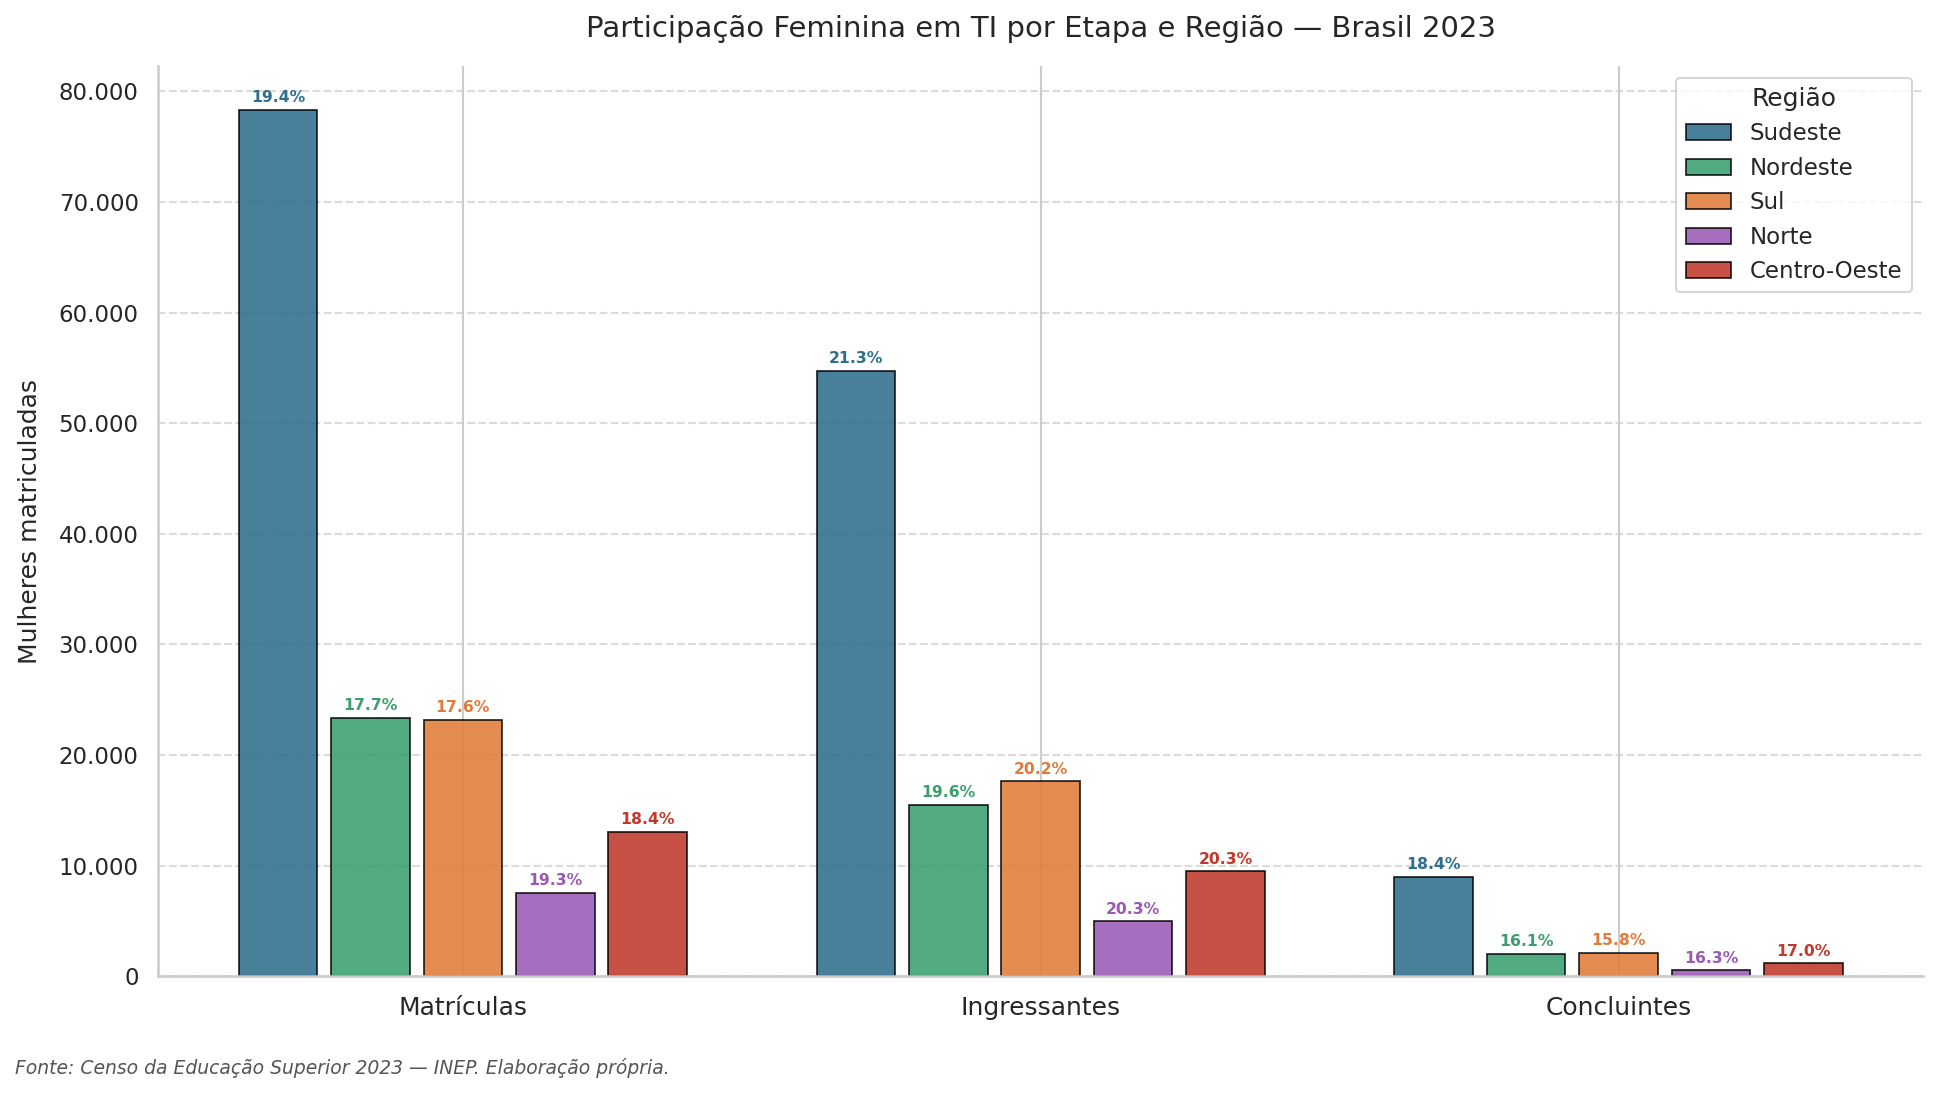

✅ Salvo: /content/outputs/graficos_censo/funil_regiao_ti.png

✅ Gráficos do Censo salvos em: /content/outputs/graficos_censo


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd
import os

xl_censo = os.path.join(OUTPUT_DIR, f'censo_ed_sup_ti_{ANO_CENSO}.xlsx')
df_geral = pd.read_excel(xl_censo, sheet_name='00_Resumo_Geral')
df_curso = pd.read_excel(xl_censo, sheet_name='01_Por_Curso')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 150})

COR_FEM  = '#2E6E8E'
COR_MASC = '#b0b0b0'
FONTE_CENSO = f'Censo da Educação Superior {ANO_CENSO} — INEP. Elaboração própria.'
GRAF_DIR_CENSO = os.path.join(OUTPUT_DIR, 'graficos_censo')
os.makedirs(GRAF_DIR_CENSO, exist_ok=True)
w = 0.38

def save_fig_censo(fname):
    path = os.path.join(GRAF_DIR_CENSO, fname)
    plt.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print('✅ Salvo:', path)

def fmt_mil(x, _):
    return f'{int(x):,}'.replace(',', '.')


# ── Totais Brasil ─────────────────────────────────────────────────
tot_ing       = df_geral['QT_ING'].sum()
tot_ing_fem   = df_geral['QT_ING_FEM'].sum()
tot_ing_masc  = df_geral['QT_ING_MASC'].sum()
tot_mat       = df_geral['QT_MAT'].sum()
tot_mat_fem   = df_geral['QT_MAT_FEM'].sum()
tot_mat_masc  = df_geral['QT_MAT_MASC'].sum()
tot_conc      = df_geral['QT_CONC'].sum()
tot_conc_fem  = df_geral['QT_CONC_FEM'].sum()
tot_conc_masc = df_geral['QT_CONC_MASC'].sum()


# ── GRÁFICO 1: Funil geral ────────────────────────────────────────
etapas    = ['Matrículas',   'Ingressantes', 'Concluintes']
fem_vals  = [tot_mat_fem,    tot_ing_fem,    tot_conc_fem]
masc_vals = [tot_mat_masc,   tot_ing_masc,   tot_conc_masc]
totais    = [tot_mat,        tot_ing,        tot_conc]

x = np.arange(len(etapas))
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, fem_vals,  width=w, label='Feminino',  color=COR_FEM,  edgecolor='black', linewidth=1.1, alpha=0.9)
b2 = ax.bar(x + w/2, masc_vals, width=w, label='Masculino', color=COR_MASC, edgecolor='black', linewidth=1.1, alpha=0.9)
for i, (fv, mv, tot) in enumerate(zip(fem_vals, masc_vals, totais)):
    ax.text(i - w/2, fv + ax.get_ylim()[1]*0.01,
            f'{fv:,}\n({100*fv/tot:.1f}%)'.replace(',','.'),
            ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, mv + ax.get_ylim()[1]*0.01,
            f'{mv:,}\n({100*mv/tot:.1f}%)'.replace(',','.'),
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(etapas, fontsize=12)
ax.set_ylabel('Estudantes', labelpad=8)
ax.set_title(f'Participação por Gênero em Cursos de TI — Brasil {ANO_CENSO}', fontsize=14, pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
fig.text(0.01, -0.03, f'Fonte: {FONTE_CENSO}', fontsize=9, color='#555555', style='italic')
plt.tight_layout()
save_fig_censo('participacao_genero_ti.png')


# ── GRÁFICO 2: Top 10 cursos ──────────────────────────────────────
top10 = (
    df_curso.groupby('NO_CINE_ROTULO')[['QT_MAT_FEM','QT_MAT_MASC','QT_MAT']]
    .sum()
    .sort_values('QT_MAT_FEM', ascending=False)
    .head(10)
    .reset_index()
)
top10['pct_fem'] = (100 * top10['QT_MAT_FEM'] / top10['QT_MAT']).round(1)

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(top10))
b1 = ax.barh(y + w/2, top10['QT_MAT_FEM'],  height=w, label='Feminino',  color=COR_FEM,  edgecolor='black', linewidth=1.1, alpha=0.9)
b2 = ax.barh(y - w/2, top10['QT_MAT_MASC'], height=w, label='Masculino', color=COR_MASC, edgecolor='black', linewidth=1.1, alpha=0.9)
max_val = top10['QT_MAT_MASC'].max()
for bar, pct in zip(b1, top10['pct_fem']):
    ax.text(bar.get_width() + max_val*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,} ({pct}%)'.replace(',','.'),
            va='center', fontsize=9, color=COR_FEM)
for bar, pct in zip(b2, top10['pct_fem']):
    ax.text(bar.get_width() + max_val*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,} ({100-pct}%)'.replace(',','.'),
            va='center', fontsize=9, color='#555555')
ax.set_yticks(y); ax.set_yticklabels(top10['NO_CINE_ROTULO'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Matrículas', labelpad=8)
ax.set_title(f'Top 10 Cursos de TI por Matrículas Femininas — Brasil {ANO_CENSO}', fontsize=14, pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
ax.legend(); ax.grid(axis='x', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
fig.text(0.01, -0.03, f'Fonte: {FONTE_CENSO}', fontsize=9, color='#555555', style='italic')
plt.tight_layout()
save_fig_censo('top10_cursos_ti.png')


# ── GRÁFICO 3: Funil feminino por região ─────────────────────────
UF_REGIAO = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}

df_geral['REGIAO'] = df_geral['SG_UF'].map(UF_REGIAO)
regioes_ord = ['Sudeste','Nordeste','Sul','Norte','Centro-Oeste']

reg = df_geral.groupby('REGIAO')[['QT_ING','QT_ING_FEM','QT_MAT','QT_MAT_FEM','QT_CONC','QT_CONC_FEM']].sum()
reg = reg.loc[regioes_ord]
reg['pct_ing']  = (100 * reg['QT_ING_FEM']  / reg['QT_ING']).round(1)
reg['pct_mat']  = (100 * reg['QT_MAT_FEM']  / reg['QT_MAT']).round(1)
reg['pct_conc'] = (100 * reg['QT_CONC_FEM'] / reg['QT_CONC']).round(1)

etapas_reg = ['Matrículas',  'Ingressantes', 'Concluintes']
cols_fem   = ['QT_MAT_FEM',  'QT_ING_FEM',  'QT_CONC_FEM']
cols_pct   = ['pct_mat',     'pct_ing',     'pct_conc']

x = np.arange(len(etapas_reg))
n = len(regioes_ord)
total_w = 0.8
bw = total_w / n
cores_reg = ['#2E6E8E','#3A9E6E','#E07B39','#9B59B6','#C0392B']

fig, ax = plt.subplots(figsize=(13, 7))
for i, (regiao, cor) in enumerate(zip(regioes_ord, cores_reg)):
    offset = -total_w/2 + i*bw + bw/2
    vals = [reg.loc[regiao, c] for c in cols_fem]
    pcts = [reg.loc[regiao, c] for c in cols_pct]
    bars = ax.bar(x + offset, vals, width=bw*0.85, label=regiao,
                  color=cor, edgecolor='black', linewidth=0.8, alpha=0.88)
    for bar, pct in zip(bars, pcts):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + ax.get_ylim()[1]*0.005,
                f'{pct}%', ha='center', va='bottom', fontsize=7.5, color=cor, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(etapas_reg, fontsize=12)
ax.set_ylabel('Mulheres matriculadas', labelpad=8)
ax.set_title(f'Participação Feminina em TI por Etapa e Região — Brasil {ANO_CENSO}', fontsize=14, pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
ax.legend(title='Região', loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7); ax.set_axisbelow(True)
fig.text(0.01, -0.03, f'Fonte: {FONTE_CENSO}', fontsize=9, color='#555555', style='italic')
plt.tight_layout()
save_fig_censo('funil_regiao_ti.png')

print(f'\n✅ Gráficos do Censo salvos em: {GRAF_DIR_CENSO}')

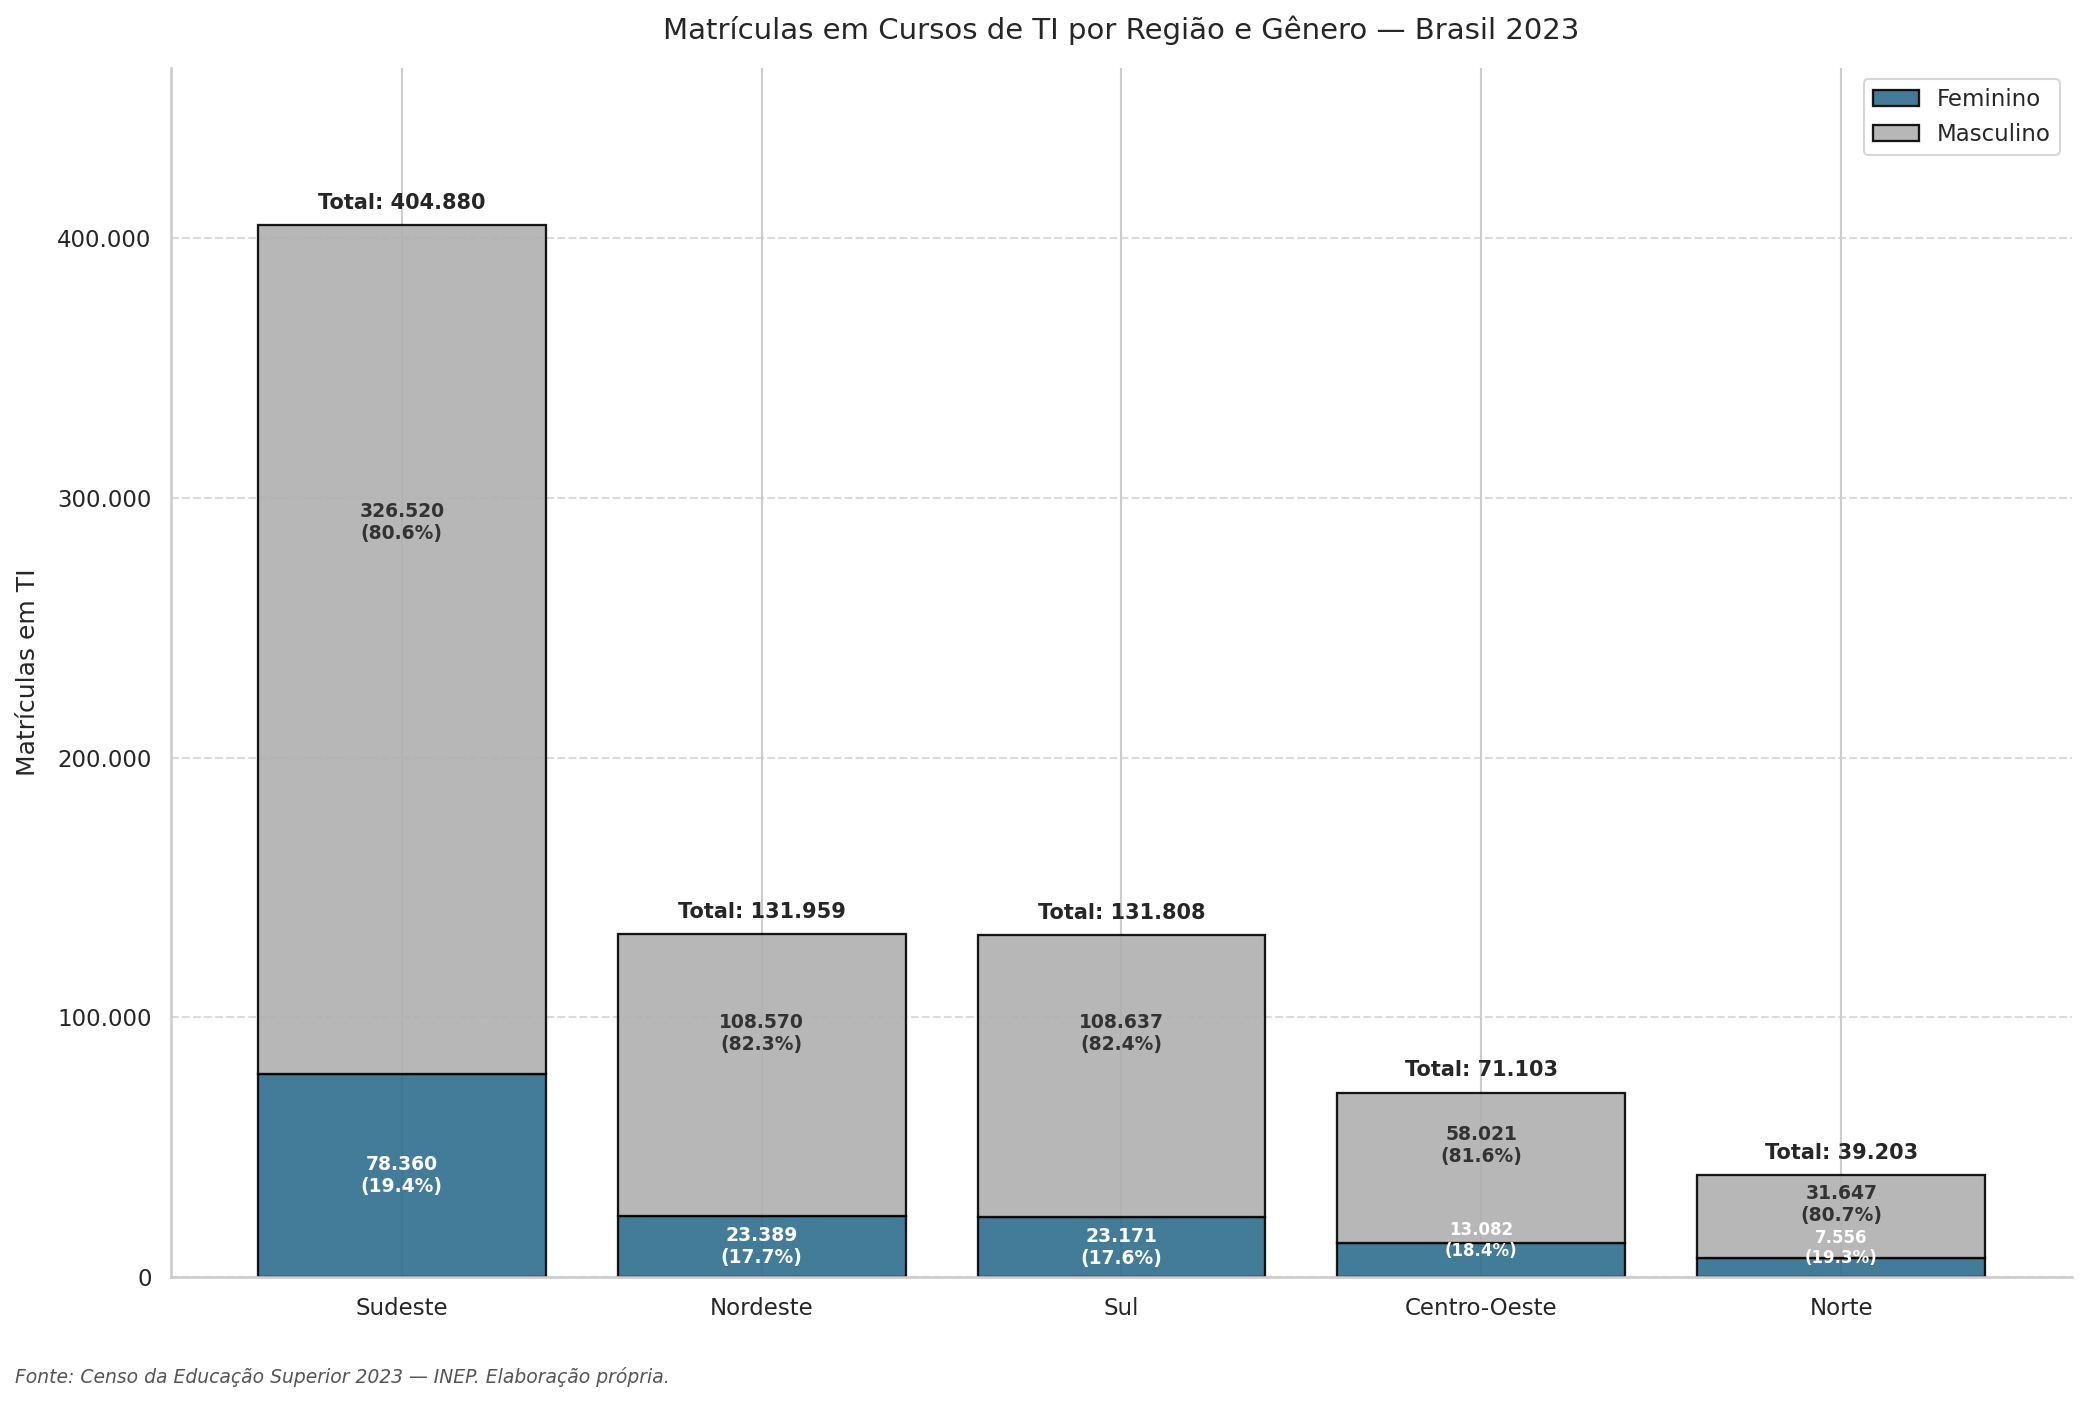

✅ Salvo: /content/outputs/graficos_censo/matriculas_regiao_genero.png


In [ ]:
# ── GRÁFICO: Matrículas em TI por região — Feminino vs Masculino ─
UF_REGIAO = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}

ti_censo['REGIAO'] = ti_censo['SG_UF'].map(UF_REGIAO)
regioes_ord = ['Sudeste','Nordeste','Sul','Centro-Oeste','Norte']

reg = (
    ti_censo.groupby('REGIAO')[['QT_MAT_FEM','QT_MAT_MASC','QT_MAT']]
    .sum()
    .loc[regioes_ord]
    .reset_index()
)
reg['pct_fem']  = (100 * reg['QT_MAT_FEM']  / reg['QT_MAT']).round(1)
reg['pct_masc'] = (100 * reg['QT_MAT_MASC'] / reg['QT_MAT']).round(1)

fig, ax = plt.subplots(figsize=(14, 9))

b1 = ax.bar(reg['REGIAO'], reg['QT_MAT_FEM'],
            label='Feminino', color=COR_FEM, edgecolor='black', linewidth=1.1, alpha=0.9)
b2 = ax.bar(reg['REGIAO'], reg['QT_MAT_MASC'],
            bottom=reg['QT_MAT_FEM'],
            label='Masculino', color=COR_MASC, edgecolor='black', linewidth=1.1, alpha=0.9)

# Rótulo feminino — dentro se barra grande, acima se pequena
for bar, pct in zip(b1, reg['pct_fem']):
    h = bar.get_height()
    if h > 15000:
        ax.text(bar.get_x() + bar.get_width()/2,
                h / 2,
                f'{int(h):,}\n({pct}%)'.replace(',','.'),
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2,
                h / 2,
                f'{int(h):,}\n({pct}%)'.replace(',','.'),
                ha='center', va='bottom', fontsize=8,
                color='white', fontweight='bold')

# Rótulo masculino dentro da barra
for bar, bot, pct in zip(b2, reg['QT_MAT_FEM'], reg['pct_masc']):
    h = bar.get_height()
    if h > 1000:
        ax.text(bar.get_x() + bar.get_width()/2,
                bot + h * 0.65,
                f'{int(h):,}\n({pct}%)'.replace(',','.'),
                ha='center', va='center', fontsize=9,
                color='#333333', fontweight='bold')

# Total no topo — MOVA set_ylim para ANTES deste loop
ax.set_ylim(0, reg['QT_MAT'].max() * 1.15)

for i, row in reg.iterrows():
    ax.text(i, row['QT_MAT'] + ax.get_ylim()[1]*0.01,
            f'Total: {int(row["QT_MAT"]):,}'.replace(',','.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Matrículas em TI', labelpad=8)
ax.set_title(f'Matrículas em Cursos de TI por Região e Gênero — Brasil {ANO_CENSO}',
             fontsize=14, pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_mil))
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
fig.text(0.01, -0.03, f'Fonte: {FONTE_CENSO}', fontsize=9, color='#555555', style='italic')
plt.tight_layout()
save_fig_censo('matriculas_regiao_genero.png')

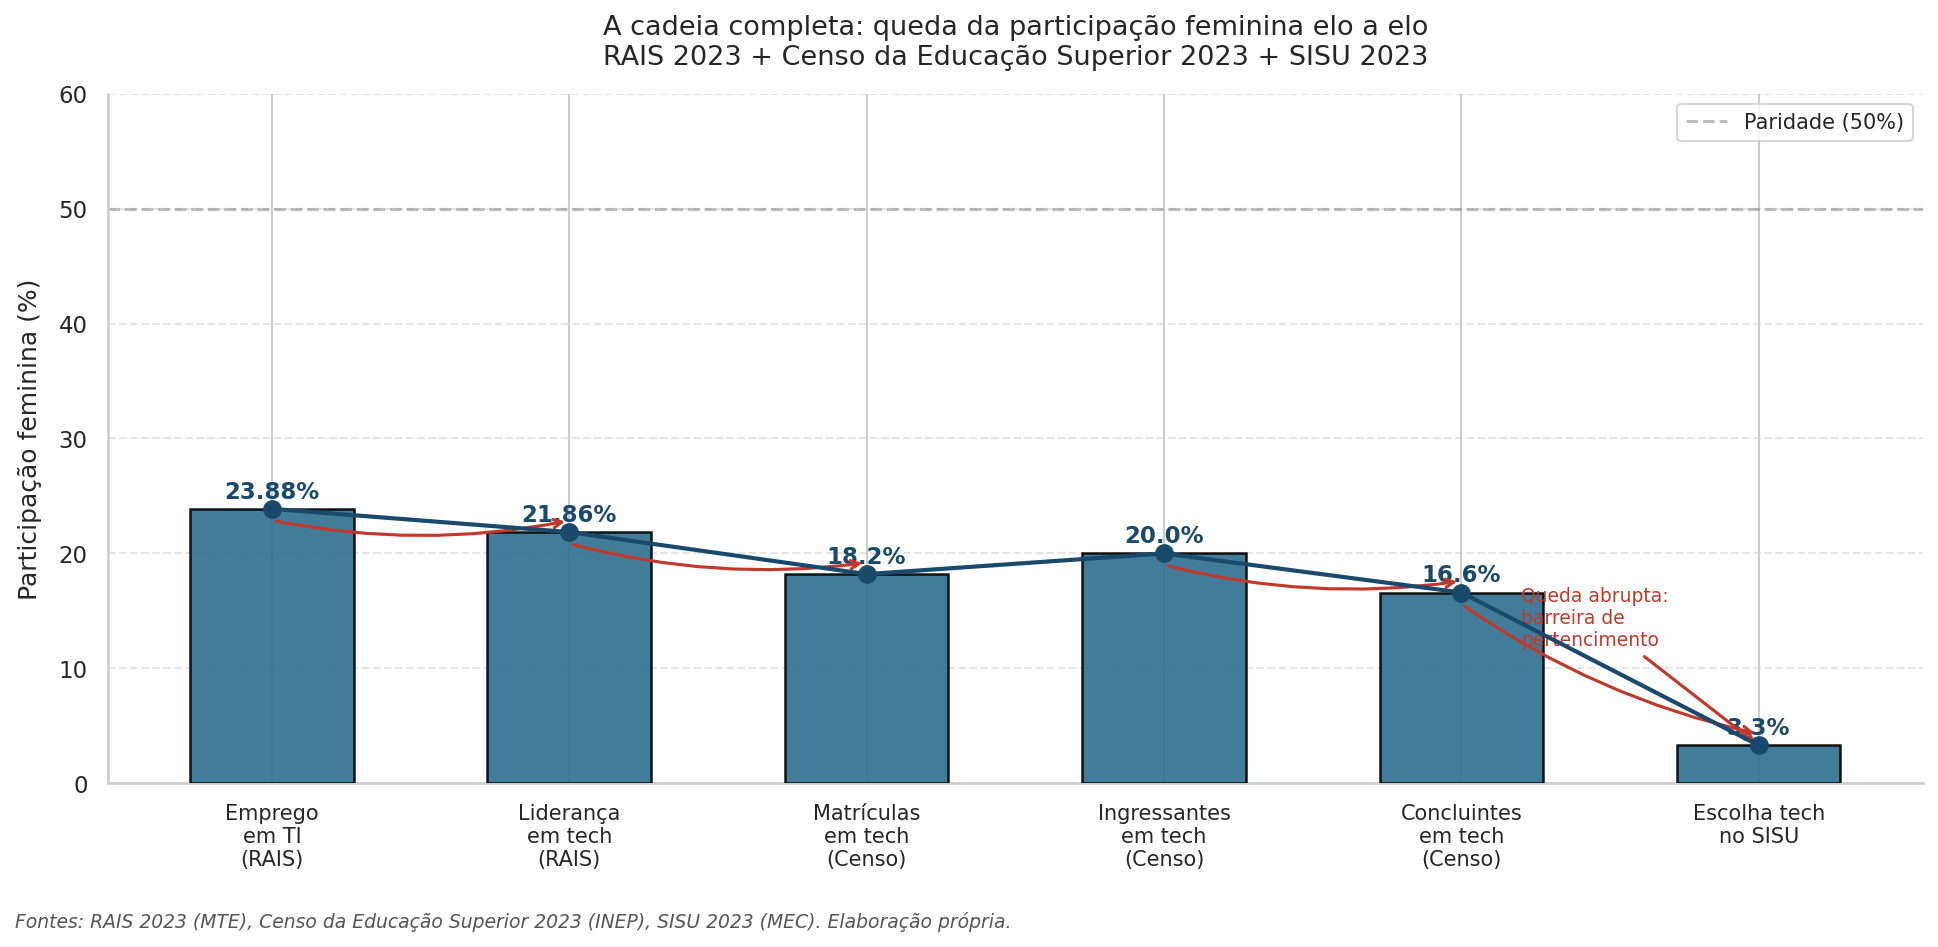

✅ Salvo: cadeia_completa.png


In [ ]:
# ── GRÁFICO: Cadeia completa — queda da participação feminina ────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(13, 6))

elos = [
    'Emprego\nem TI\n(RAIS)',
    'Liderança\nem tech\n(RAIS)',
    'Matrículas\nem tech\n(Censo)',
    'Ingressantes\nem tech\n(Censo)',
    'Concluintes\nem tech\n(Censo)',
    'Escolha tech\nno SISU',
]
valores_fem = [23.88, 21.86, 18.2, 20.0, 16.6, 3.3]
x = np.arange(len(elos))

# Barras feminino
bars = ax.bar(x, valores_fem, color='#2E6E8E', edgecolor='black',
              linewidth=1.2, alpha=0.9, width=0.55, zorder=3)

# Linha conectando os pontos
ax.plot(x, valores_fem, color='#1a4a6b', linewidth=2,
        marker='o', markersize=8, zorder=4)

# Rótulos em cima de cada barra
for i, (bar, val) in enumerate(zip(bars, valores_fem)):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.5,
            f'{val}%',
            ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#1a4a6b')

# Linha de referência 50% (paridade)
ax.axhline(50, linestyle='--', color='gray', alpha=0.5,
           label='Paridade (50%)', zorder=2)

# Setas de queda entre elos relevantes
for i in range(len(valores_fem) - 1):
    diff = valores_fem[i+1] - valores_fem[i]
    if diff < 0:
        ax.annotate('', xy=(x[i+1], valores_fem[i+1] + 1),
                    xytext=(x[i], valores_fem[i] - 1),
                    arrowprops=dict(arrowstyle='->', color='#c0392b',
                                   lw=1.5, connectionstyle='arc3,rad=0.1'))

# Destaque especial no SISU (queda abrupta)
ax.annotate('Queda abrupta:\nbarreira de\npertencimento',
            xy=(5, 3.3), xytext=(4.2, 12),
            fontsize=9, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(elos, fontsize=10)
ax.set_ylabel('Participação feminina (%)', labelpad=8)
ax.set_ylim(0, 60)
ax.set_title('A cadeia completa: queda da participação feminina elo a elo\nRAIS 2023 + Censo da Educação Superior 2023 + SISU 2023',
             fontsize=13, pad=14)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Fonte
fig.text(0.01, -0.04,
         'Fontes: RAIS 2023 (MTE), Censo da Educação Superior 2023 (INEP), SISU 2023 (MEC). Elaboração própria.',
         fontsize=9, color='#555555', style='italic')

plt.tight_layout()
plt.savefig(os.path.join(GRAF_DIR_CENSO, 'cadeia_completa.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Salvo: cadeia_completa.png')